In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_adapter_results(input_df, adapters=None, title='Accuracy vs Negative Shift Count'):
    """
    Plots Accuracy vs Negative Shift Count for specified adapters.

    Args:
        input_df (pd.DataFrame): The dataframe containing the results.
        adapters (list or str, optional): Adapter(s) to include.
            Can be a single string like 'lora' or a list like ['lora', 'vera'].
            If None, plots all adapters found in the dataframe.
        title (str): Title for the plot.
    """
    if isinstance(adapters, str):
        adapters = [adapters]

    df = input_df.copy()

    df['lr'] = pd.to_numeric(df['lr'], errors='coerce')
    df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
    df['negative_shift_count'] = pd.to_numeric(df['negative_shift_count'], errors='coerce')

    plot_df = df.dropna(subset=['accuracy', 'negative_shift_count', 'lr'])

    if adapters is not None:
        plot_df = plot_df[plot_df['adapter_type'].isin(adapters)]

    if plot_df.empty:
        print("No data to plot for the selected adapters.")
        return

    # Print learning rates tested per adapter
    print("Learning rates tested:")
    for adapter in sorted(plot_df['adapter_type'].unique()):
        lrs = sorted(plot_df[plot_df['adapter_type'] == adapter]['lr'].unique())
        lr_str = ', '.join(f'{lr:.1e}' for lr in lrs)
        print(f"  {adapter}: [{lr_str}]")
    print()

    plt.figure(figsize=(14, 6))

    markers = {
        'lora': 'o',
        'uiortholora': 'X',
        'vera': 's',
        'dora': 'D'
    }

    norm = colors.LogNorm(vmin=plot_df['lr'].min(), vmax=plot_df['lr'].max())

    sc = None
    for adapter in plot_df['adapter_type'].unique():
        subset = plot_df[plot_df['adapter_type'] == adapter]
        marker = markers.get(adapter, 'o')
        sc = plt.scatter(
            x=subset['negative_shift_count'],
            y=subset['accuracy'],
            c=subset['lr'],
            norm=norm,
            marker=marker,
            cmap='viridis',
            s=100,
            alpha=0.8,
            edgecolors='w',
            label=adapter
        )

    if sc:
        cbar = plt.colorbar(sc)
        cbar.set_label('Learning Rate (Log Scale)')

    plt.legend(title='Adapter Type')
    plt.title(title)
    plt.xlabel('Negative Shift Count (Forgetting)')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_lora(df, **kwargs):
    plot_adapter_results(df, adapters='lora', title='LoRA: Accuracy vs Negative Shift Count', **kwargs)

def plot_ortholora(df, **kwargs):
    plot_adapter_results(df, adapters='uiortholora', title='OrthoLoRA: Accuracy vs Negative Shift Count', **kwargs)

def plot_vera(df, **kwargs):
    plot_adapter_results(df, adapters='vera', title='VeRA: Accuracy vs Negative Shift Count', **kwargs)

def plot_dora(df, **kwargs):
    plot_adapter_results(df, adapters='dora', title='DoRA: Accuracy vs Negative Shift Count', **kwargs)

In [19]:
file_path = 'adapters_results/hotpotqa/threshold_0.8/gemma-12b.csv'
df = pd.read_csv(file_path)
# plot_adapter_results(df, adapters=['lora', 'vera', 'uiortholora', 'dora'])


Learning rates tested:
  lora: [1.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 7.0e-03, 1.0e-02]



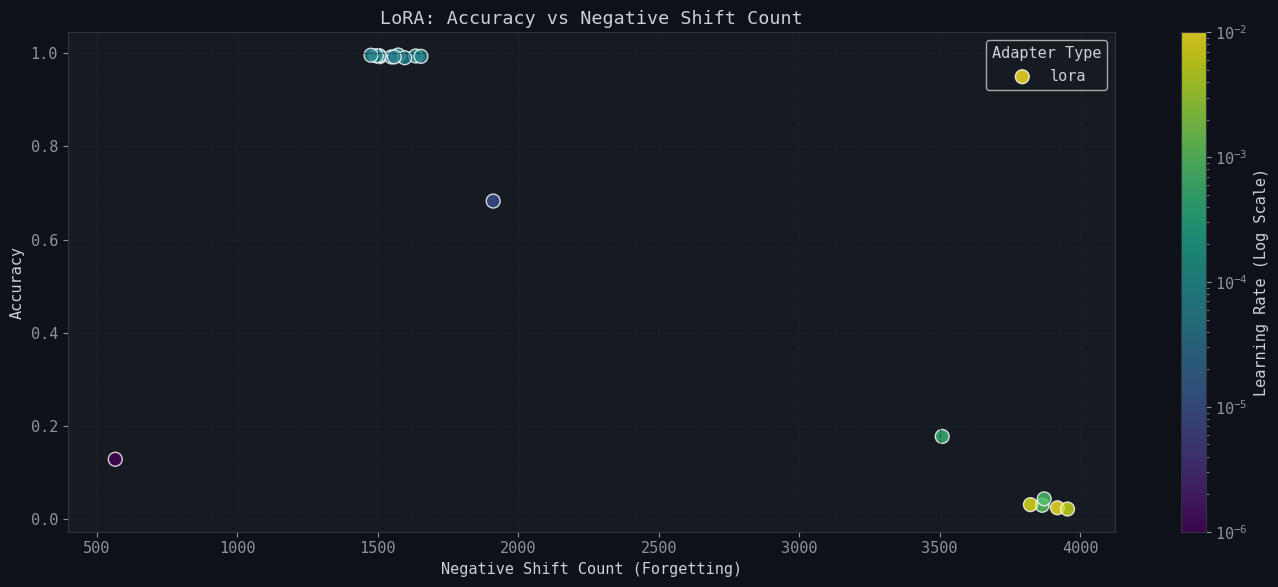

Learning rates tested:
  uiortholora: [1.0e-06, 5.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 6.0e-03, 7.0e-03, 8.0e-03, 9.0e-03, 1.0e-02, 2.0e-02, 4.0e-02, 1.0e-01, 3.0e-01, 5.0e-01]



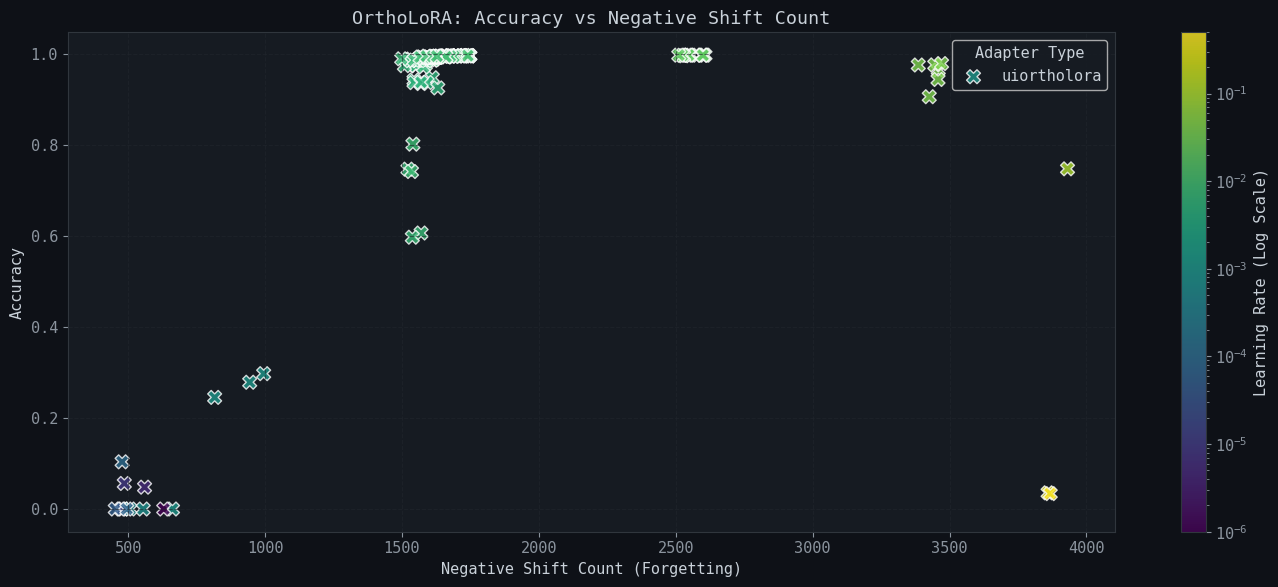

Learning rates tested:
  vera: [1.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 7.0e-03, 1.0e-02]



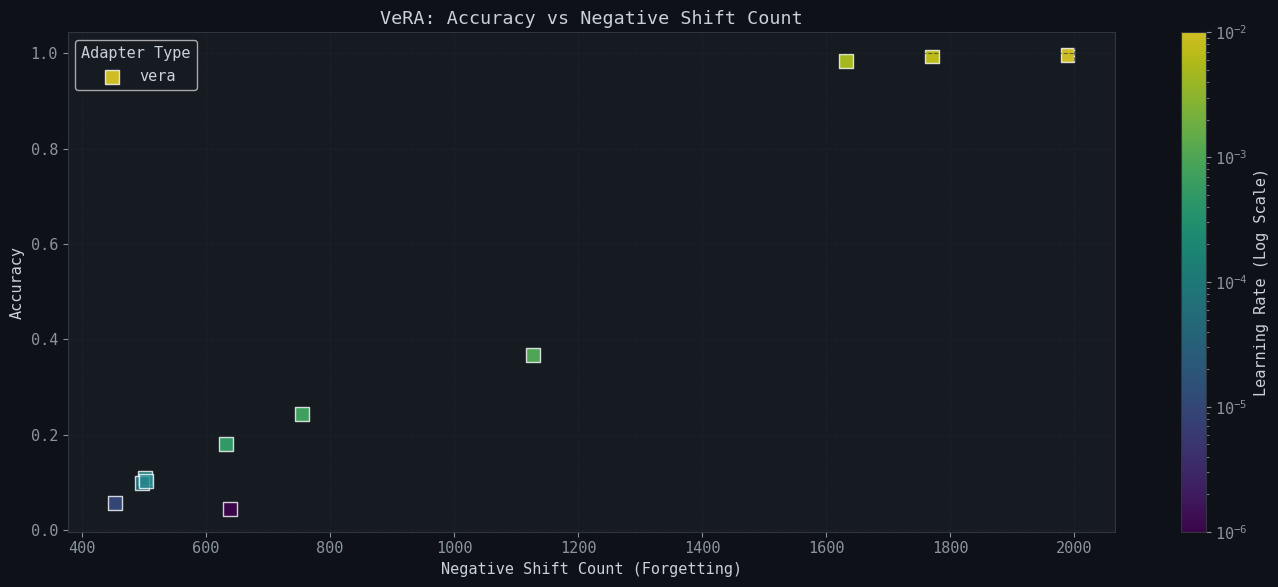

Learning rates tested:
  dora: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02]



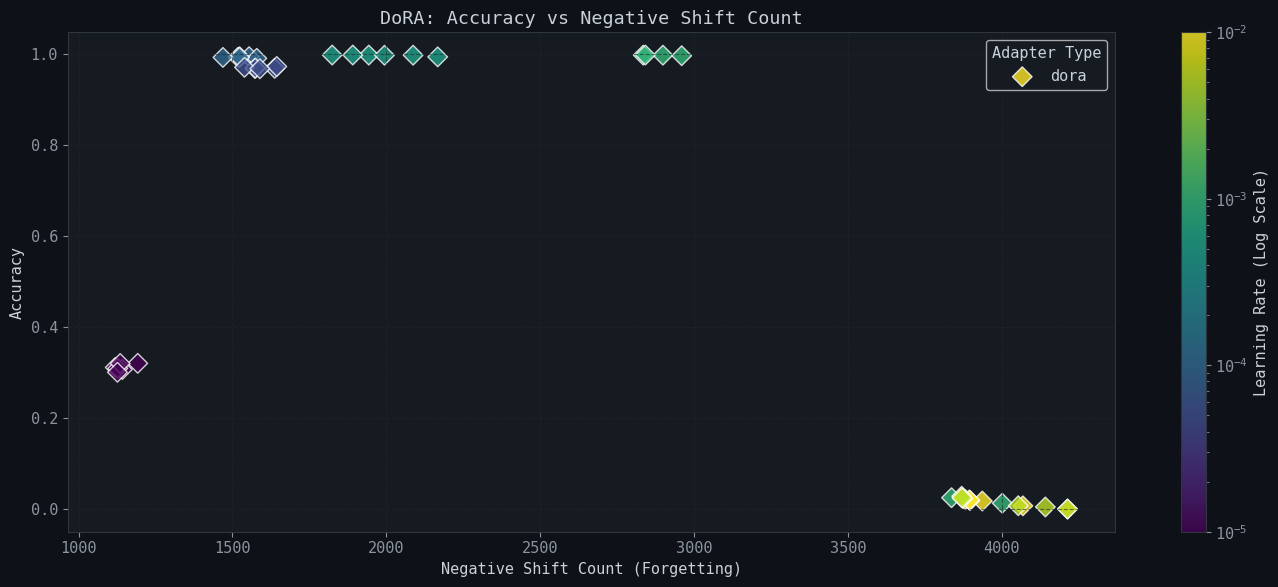

In [20]:
plot_lora(df)
plot_ortholora(df)
plot_vera(df)
plot_dora(df)

Learning rates tested:
  dora: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02]
  lora: [5.0e-06, 1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03]
  uiortholora: [1.0e-04, 5.0e-04, 5.0e-03, 7.0e-03, 9.0e-03, 1.0e-02, 2.0e-02, 4.0e-02, 5.0e-02, 6.0e-02]
  vera: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 5.0e-02]



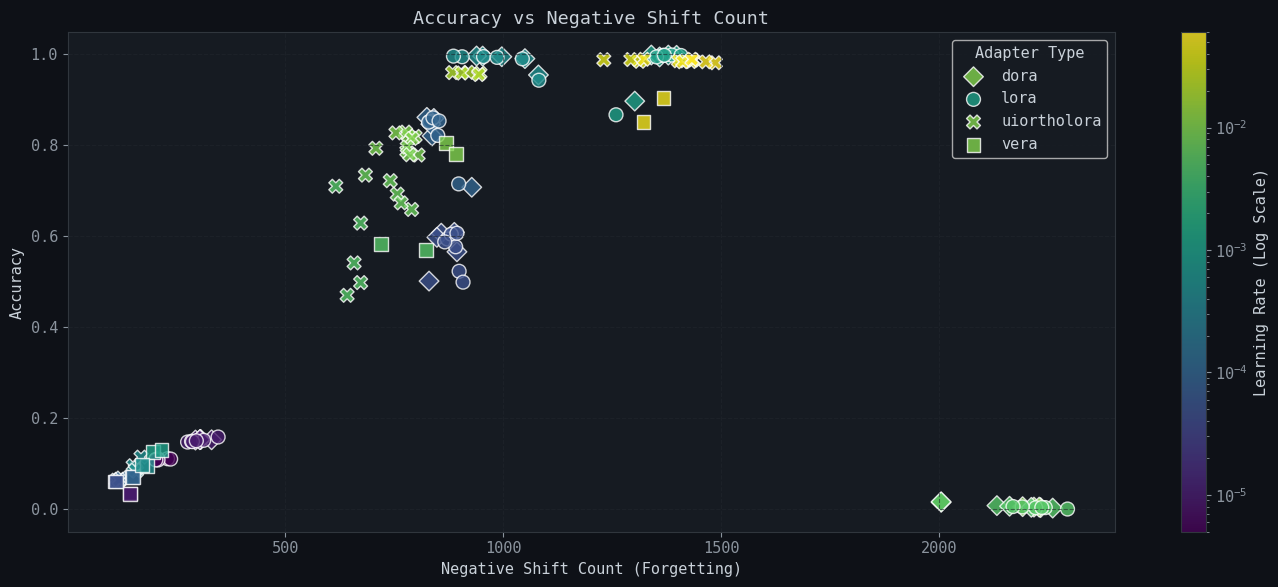

In [21]:
file_path = 'adapters_results/hotpotqa/threshold_0.8/llama-3b.csv'
df = pd.read_csv(file_path)
plot_adapter_results(df, adapters=['lora', 'vera', 'uiortholora', 'dora'])

Learning rates tested:
  dora: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02]
  lora: [5.0e-05]
  uiortholora: [5.0e-04, 8.0e-04, 1.0e-03, 3.0e-03, 4.0e-03, 5.0e-03, 6.0e-03, 7.0e-03, 8.0e-03, 9.0e-03, 1.0e-02, 2.0e-02, 1.0e-01, 3.0e-01]
  vera: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 5.0e-02]



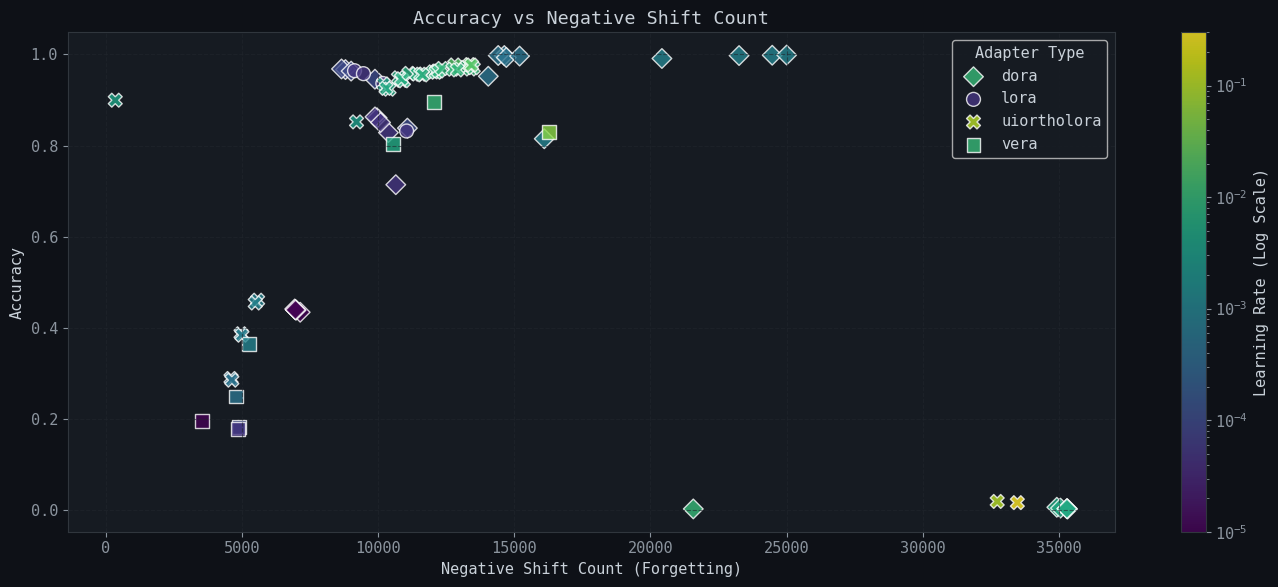

In [22]:
file_path = 'adapters_results/triviaqa/threshold_0.8/llama-3b.csv'
df = pd.read_csv(file_path)
plot_adapter_results(df, adapters=['lora', 'vera', 'uiortholora', 'dora'])

Learning rates tested:
  dora: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04]
  lora: [5.0e-06, 1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03]
  uiortholora: [1.0e-04, 5.0e-04, 5.0e-03, 7.0e-03, 8.0e-03, 9.0e-03, 1.0e-02, 2.0e-02, 5.0e-02, 1.0e-01, 3.0e-01, 5.0e-01]
  vera: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 5.0e-02]



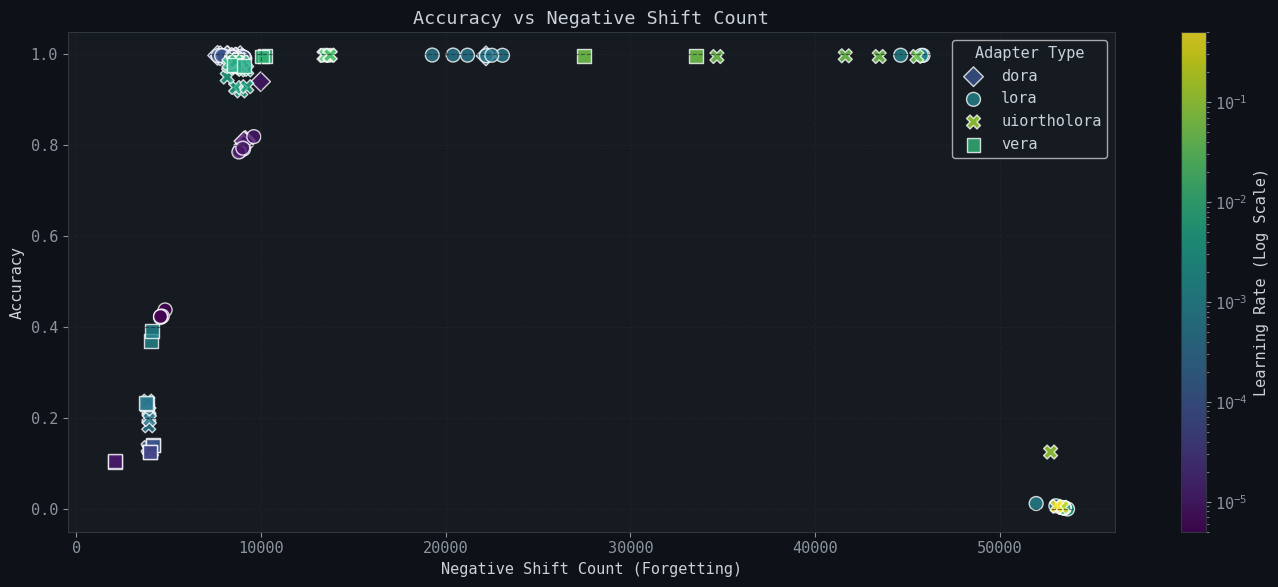

In [23]:
file_path = 'adapters_results/triviaqa/threshold_0.8/gemma-12b.csv'
df = pd.read_csv(file_path)
plot_adapter_results(df, adapters=['lora', 'vera', 'uiortholora', 'dora'])

Learning rates tested:
  dora: [1.0e-05, 5.0e-05, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02]
  lora: [1.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 7.0e-03, 1.0e-02]
  uiortholora: [1.0e-06, 5.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 6.0e-03, 7.0e-03, 8.0e-03, 9.0e-03, 1.0e-02, 2.0e-02, 4.0e-02, 1.0e-01, 3.0e-01, 5.0e-01]
  vera: [1.0e-06, 1.0e-05, 5.0e-05, 7.0e-05, 1.0e-04, 5.0e-04, 7.0e-04, 1.0e-03, 5.0e-03, 7.0e-03, 1.0e-02]



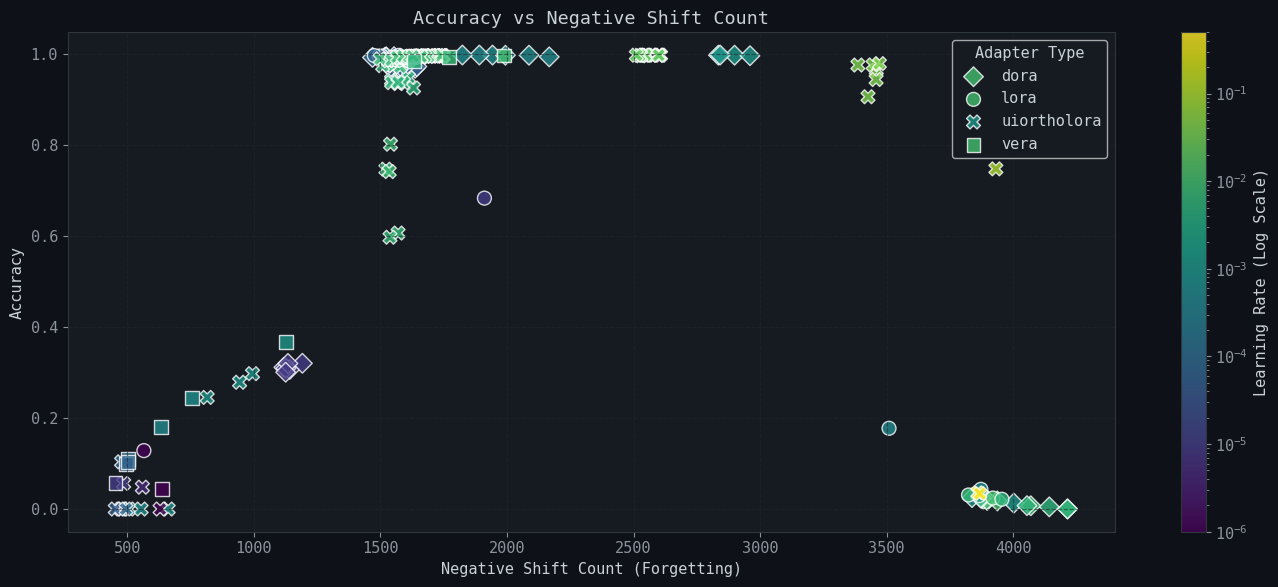

In [24]:
file_path = 'adapters_results/hotpotqa/threshold_0.8/gemma-12b.csv'
df = pd.read_csv(file_path)
plot_adapter_results(df, adapters=['lora', 'vera', 'uiortholora', 'dora'])

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import re
import numpy as np

def extract_metadata(df, name_col='model_path'):
    """
    Extracts adapter_type, rank, and lr from a naming column if they are missing.
    Returns the dataframe with standardized columns.
    """
    df = df.copy()
    
    # 1. Standardize Adapter Type
    # If peft_method exists, use it; otherwise extract from name
    if 'peft_method' in df.columns:
        df['adapter_type'] = df['peft_method'].fillna('')
    else:
        df['adapter_type'] = ''
        
    # In extract_metadata, update get_adapter:
    def get_adapter(row):
        val = str(row.get('adapter_type', '')).lower()
        name = str(row[name_col]).lower()
        if val in ['lora', 'vera', 'uiortholora', 'dora']:
            return val
        if 'uiortho' in name: return 'uiortholora'
        if 'dora' in name: return 'dora'       # <-- BEFORE 'lora' check!
        if 'vera' in name: return 'vera'
        if 'lora' in name: return 'lora'
        return 'unknown'

    df['adapter_type'] = df.apply(get_adapter, axis=1)

    # 2. Extract Learning Rate (LR)
    def get_lr(row):
        # Prefer explicit column
        if 'learning_rate' in row and pd.notnull(row['learning_rate']):
            return float(row['learning_rate'])
        if 'lr' in row and pd.notnull(row['lr']):
            return float(row['lr'])
        
        # Regex extract from name (looks for lr1e-4, lr5e-5, etc.)
        match = re.search(r'lr([\de.-]+)', str(row[name_col]))
        if match:
            try:
                return float(match.group(1))
            except:
                return np.nan
        return np.nan

    df['lr'] = df.apply(get_lr, axis=1)

    # 3. Extract Rank/Size
    def get_rank(row):
        # Prefer explicit column
        if 'rank' in row and pd.notnull(row['rank']):
            return int(float(row['rank']))
        
        name = str(row[name_col])
        # Check for svXXXX (uiortholora)
        match_sv = re.search(r'_sv(\d+)', name)
        if match_sv: return int(match_sv.group(1))
        
        # Check for rXXXX (lora/vera)
        match_r = re.search(r'_r(\d+)', name)
        if match_r: return int(match_r.group(1))
        
        return 0

    df['rank'] = df.apply(get_rank, axis=1)
    
    return df

def plot_performance_tradeoff(df, x_col, y_col, title=None, x_label=None, y_label=None):
    """
    Plots Y (Task Accuracy) vs X (General Accuracy/Forgetting).
    """
    # Drop rows missing crucial data
    plot_df = df.dropna(subset=[x_col, y_col, 'lr'])
    
    if plot_df.empty:
        print(f"No data available to plot for {x_col} vs {y_col}")
        return

    plt.figure(figsize=(12, 7))

    # Define markers
    markers = {
        'lora': 'o',          # Circle
        'uiortholora': 'X',   # X shape
        'vera': 's',          # Square
        'unknown': 'v'
    }

    # Normalize colors for LR
    try:
        norm = colors.LogNorm(vmin=plot_df['lr'].min(), vmax=plot_df['lr'].max())
    except ValueError:
        # Fallback if LRs are identical or invalid
        norm = None

    sc = None
    adapters = plot_df['adapter_type'].unique()
    
    for adapter in adapters:
        subset = plot_df[plot_df['adapter_type'] == adapter]
        marker = markers.get(adapter, 'o')
        
        sc = plt.scatter(
            x=subset[x_col],
            y=subset[y_col],
            c=subset['lr'],
            norm=norm,
            marker=marker,
            cmap='viridis',
            s=120,
            alpha=0.85,
            edgecolors='k',
            linewidth=0.5,
            label=adapter
        )

    # Aesthetics
    if sc and norm:
        cbar = plt.colorbar(sc)
        cbar.set_label('Learning Rate (Log Scale)', fontsize=12)
    
    plt.legend(title='Adapter Type', fontsize=10, title_fontsize=12)
    plt.title(title if title else f'{y_col} vs {x_col}', fontsize=16)
    plt.xlabel(x_label if x_label else x_col, fontsize=14)
    plt.ylabel(y_label if y_label else y_col, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def align_and_merge(df_task, df_general, general_name_col='model_name', 
                    task_name_col='raw_adapter_name', suffixes=('_task', '_gen')):
    """
    Aligns task results with general benchmark results (MMLU, BigBench, etc.)
    by extracting the adapter name from potentially nested path columns.
    """
    df_general = df_general.copy()
    
    # Strip to just the adapter name (last path segment, remove 'models/' prefix)
    df_general['merge_key'] = (
        df_general[general_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    # Also normalize task side in case it has paths too
    df_task = df_task.copy()
    df_task['merge_key'] = (
        df_task[task_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    merged = pd.merge(
        df_task,
        df_general,
        on='merge_key',
        suffixes=suffixes
    )
    
    merged = extract_metadata(merged, name_col='merge_key')
    
    print(f"Merged rows: {len(merged)} "
          f"(task: {len(df_task)}, general: {len(df_general)}, "
          f"unmatched task: {len(df_task) - len(merged)})")
    
    return merged

In [2]:
def load_and_merge(model, task, threshold='0.8', filter_fn=None):
    """
    Load task, MMLU, and BigBench data for a given model/task config
    and return merged DataFrames ready for plotting.
    
    Parameters:
        model: 'gemma-12b' or 'llama-3b'
        task: 'triviaqa' or 'hotpotqa'
        threshold: threshold string (default '0.8')
        filter_fn: optional function to filter the merged DataFrames
    
    Returns:
        (merged_mmlu, merged_bigbench) tuple of DataFrames
    """
    file_path = f'adapters_results/{task}/threshold_{threshold}/{model}.csv'
    mmlu_path = f'adapters_results/{task}/mmlu_summary.csv'
    bigbench_path = f'adapters_results/{task}/bigbench_summary.csv'

    df_task = pd.read_csv(file_path)
    df_mmlu = pd.read_csv(mmlu_path)
    df_bigbench = pd.read_csv(bigbench_path)

    print(f"=== {model} / {task} ===")
    merged_mmlu = align_and_merge(df_task, df_mmlu, general_name_col='model_name')
    merged_bigbench = align_and_merge(df_task, df_bigbench, general_name_col='model_path')

    if filter_fn:
        merged_mmlu = filter_fn(merged_mmlu)
        merged_bigbench = filter_fn(merged_bigbench)
        print(f"After filter: MMLU={len(merged_mmlu)}, BigBench={len(merged_bigbench)}")

    return merged_mmlu, merged_bigbench

In [3]:
lora_r1_plus_others = lambda df: df[(df['adapter_type'] != 'lora') | (df['rank'] == 1)]
final_filter = lambda df: df
# final_filter = lora_r1_plus_others

# Load all 4 configs
gemma_trivia_mmlu, gemma_trivia_bb = load_and_merge('gemma-12b', 'triviaqa', filter_fn=final_filter)
gemma_hotpot_mmlu, gemma_hotpot_bb = load_and_merge('gemma-12b', 'hotpotqa', filter_fn=final_filter)
llama_trivia_mmlu, llama_trivia_bb = load_and_merge('llama-3b', 'triviaqa', filter_fn=final_filter)
llama_hotpot_mmlu, llama_hotpot_bb = load_and_merge('llama-3b', 'hotpotqa', filter_fn=final_filter)

# Plot any of them
def plot_config(merged_mmlu, merged_bigbench, model, task):
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    
    plot_performance_tradeoff(
        merged_mmlu, x_col='mmlu_acc', y_col='accuracy',
        title=f'{task_label} vs MMLU ({model})',
        x_label='MMLU Accuracy',
        y_label=f'{task_label} Accuracy'
    )
    plot_performance_tradeoff(
        merged_bigbench, x_col='mean_accuracy', y_col='accuracy',
        title=f'{task_label} vs BigBench ({model})',
        x_label='BigBench Accuracy',
        y_label=f'{task_label} Accuracy'
    )

=== gemma-12b / triviaqa ===
Merged rows: 140 (task: 120, general: 184, unmatched task: -20)
Merged rows: 146 (task: 120, general: 190, unmatched task: -26)
After filter: MMLU=140, BigBench=146
=== gemma-12b / hotpotqa ===
Merged rows: 218 (task: 200, general: 314, unmatched task: -18)
Merged rows: 221 (task: 200, general: 321, unmatched task: -21)
After filter: MMLU=218, BigBench=221
=== llama-3b / triviaqa ===
Merged rows: 107 (task: 98, general: 184, unmatched task: -9)
Merged rows: 109 (task: 98, general: 190, unmatched task: -11)
After filter: MMLU=107, BigBench=109
=== llama-3b / hotpotqa ===
Merged rows: 173 (task: 141, general: 314, unmatched task: -32)
Merged rows: 178 (task: 141, general: 321, unmatched task: -37)
After filter: MMLU=173, BigBench=178


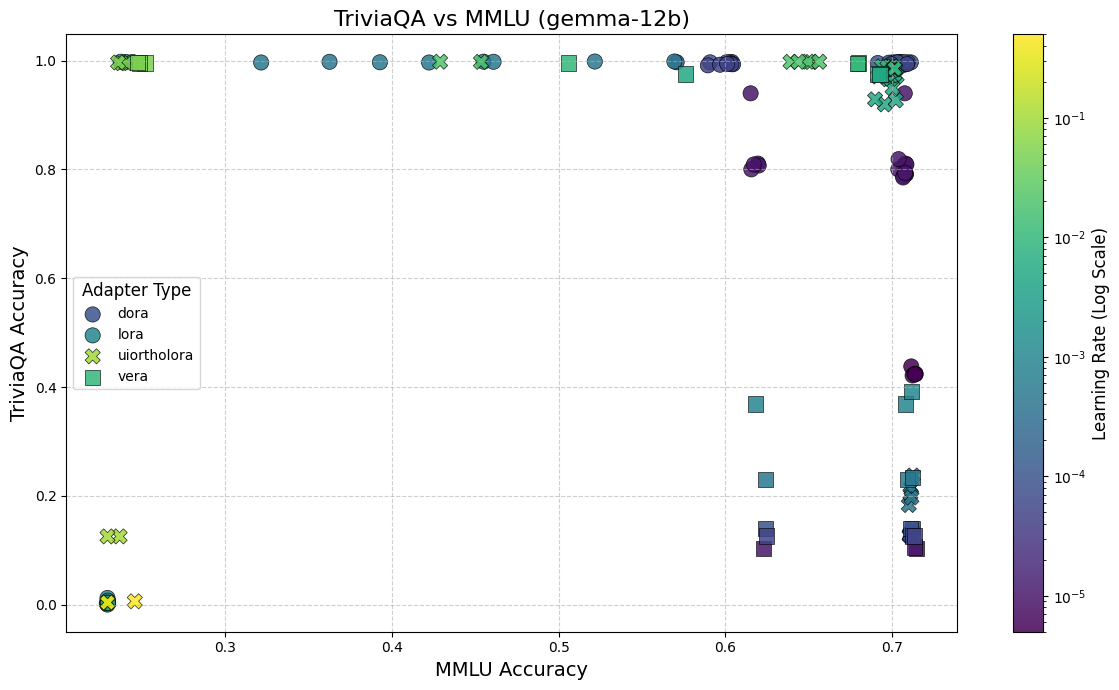

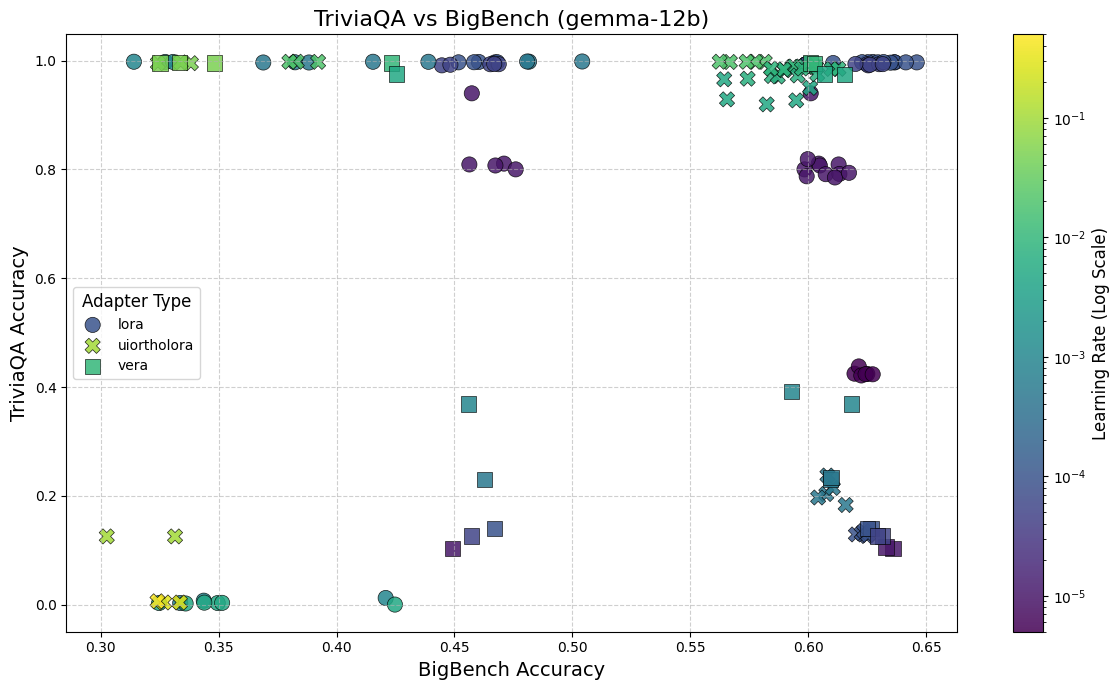

In [4]:
plot_config(gemma_trivia_mmlu, gemma_trivia_bb, 'gemma-12b', 'triviaqa')

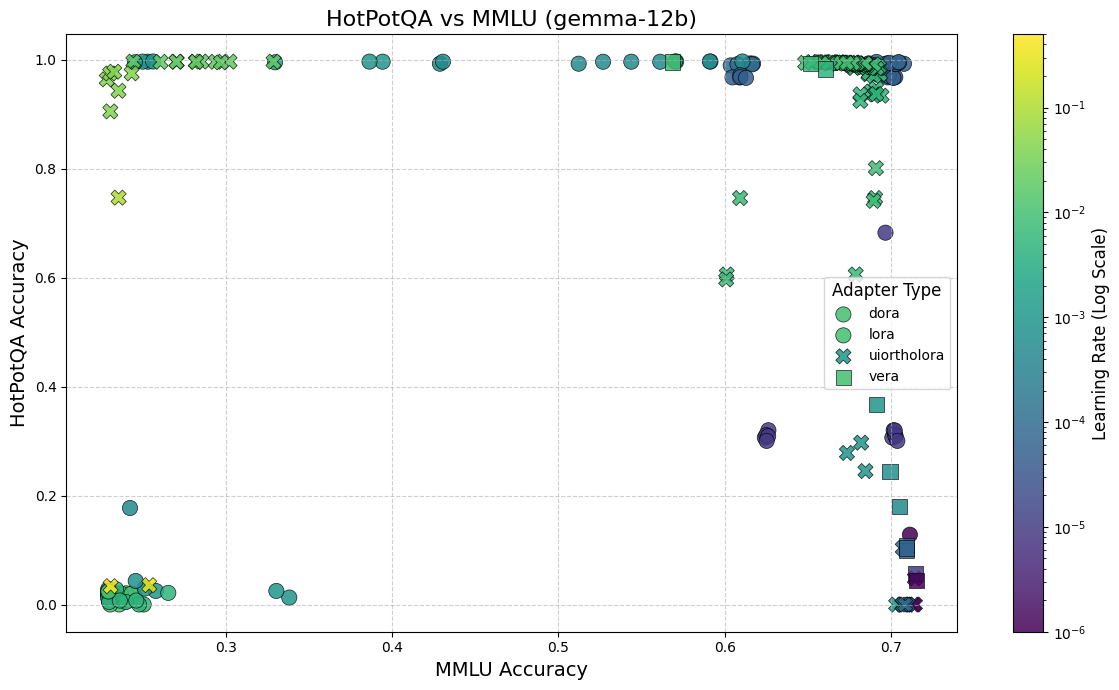

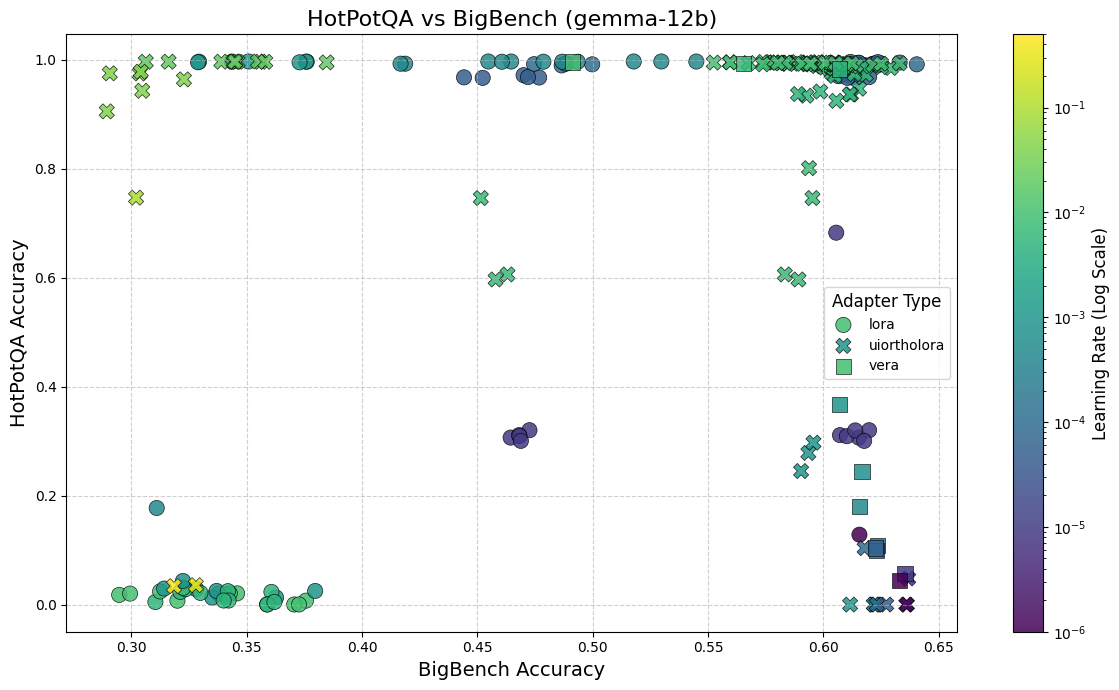

In [5]:
plot_config(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpotqa')

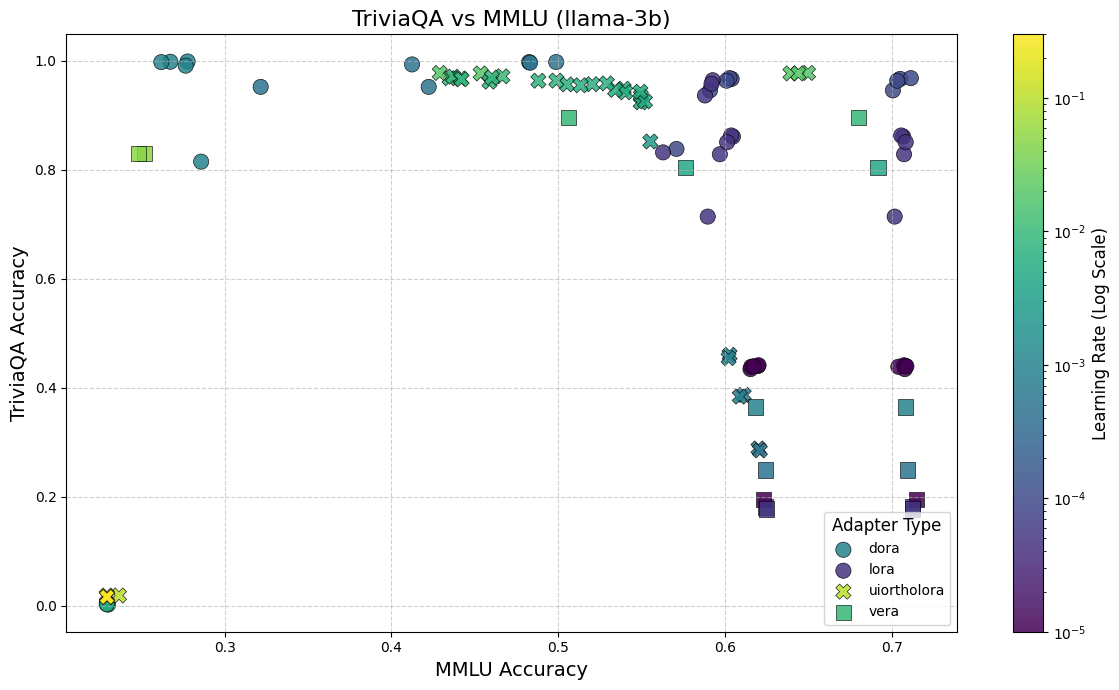

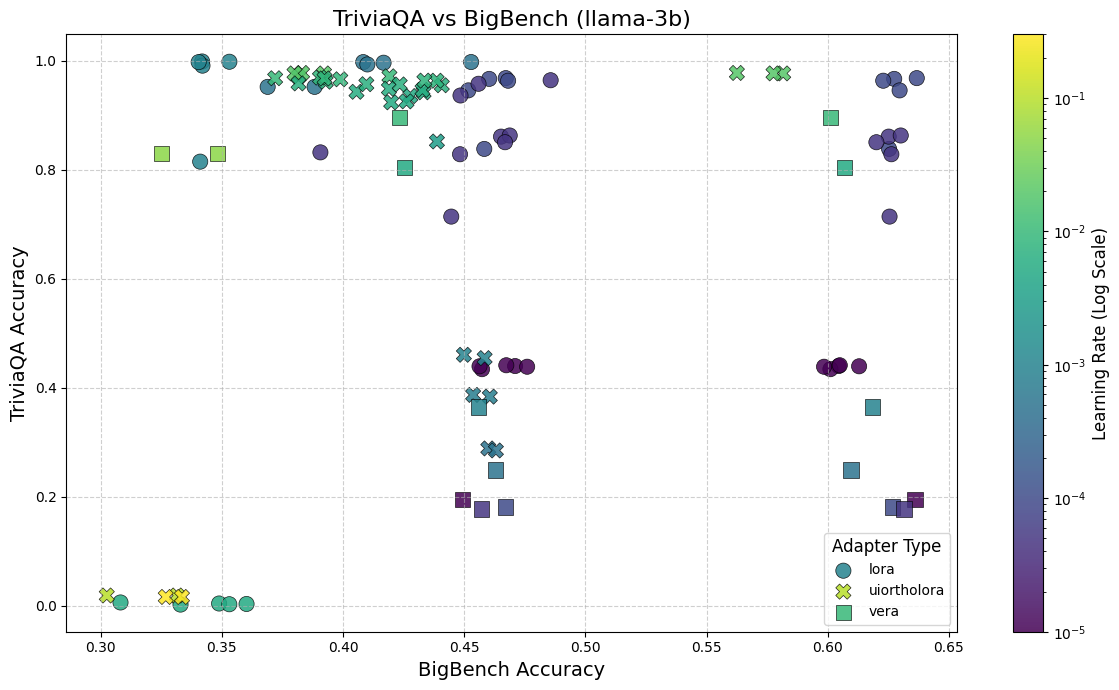

In [6]:
plot_config(llama_trivia_mmlu, llama_trivia_bb, 'llama-3b', 'triviaqa')

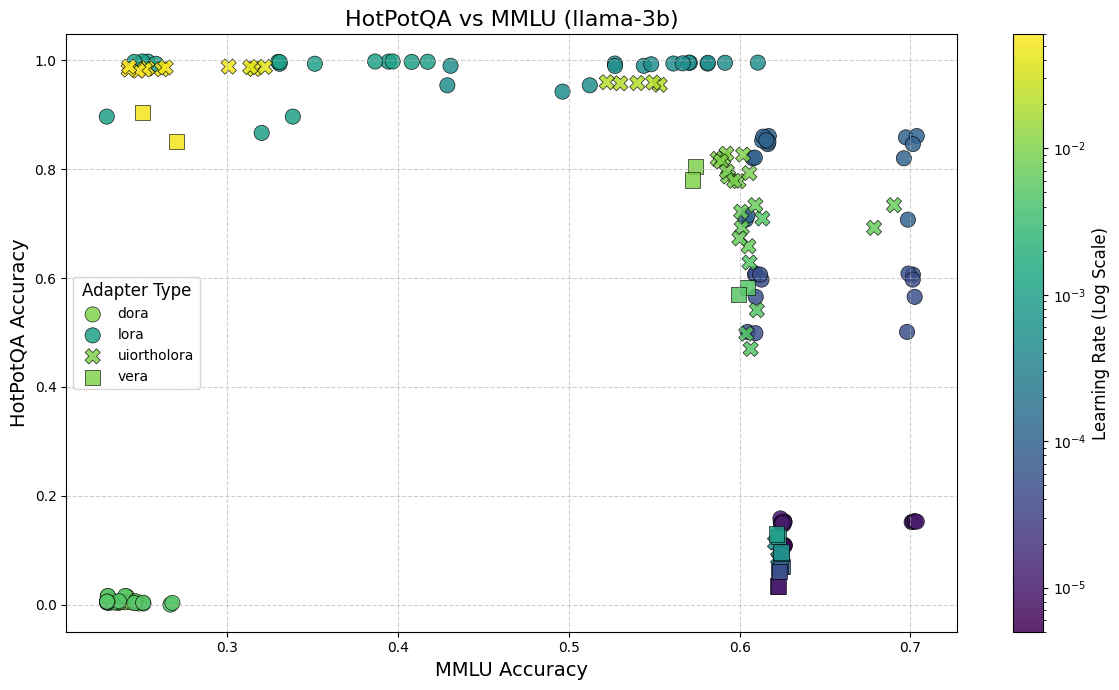

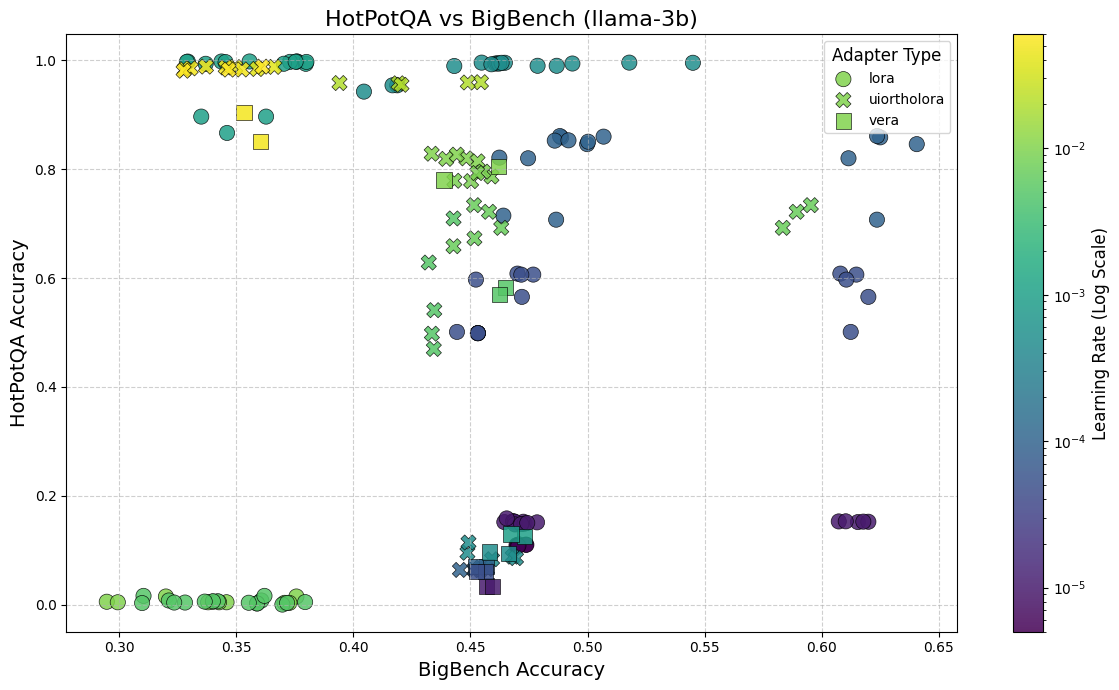

In [7]:
plot_config(llama_hotpot_mmlu, llama_hotpot_bb, 'llama-3b', 'hotpotqa')

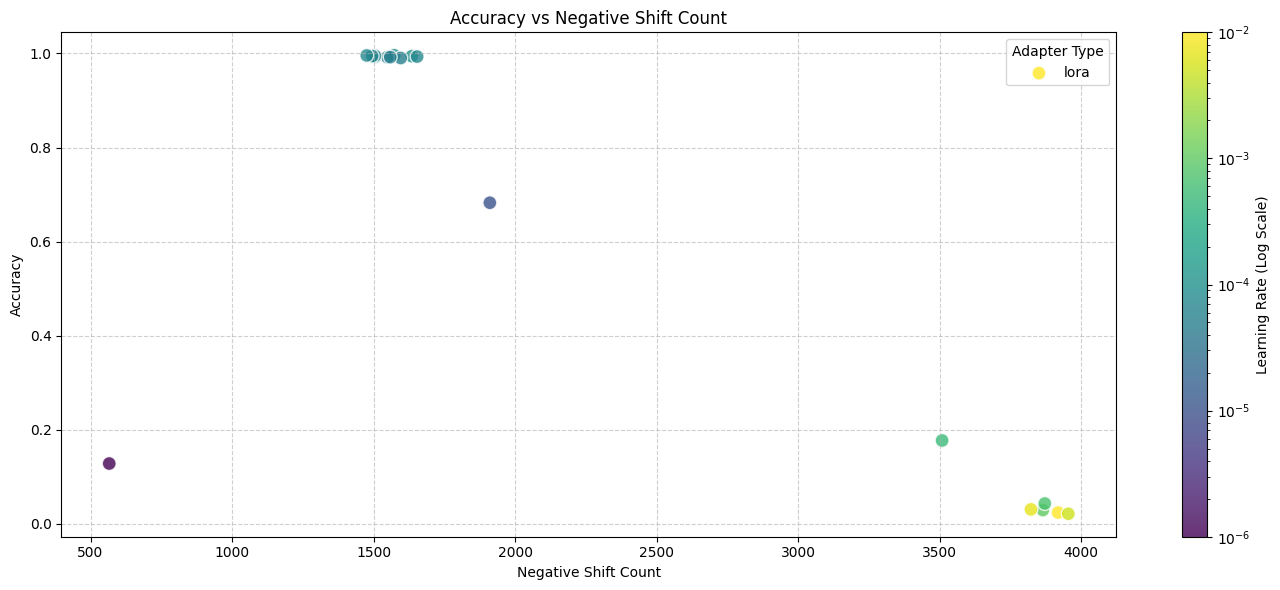

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. Setup path (Replace with your actual file path)
file_path = 'adapters_results/hotpotqa/threshold_0.8/gemma-12b.csv'

# 2. Load Data
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"File not found at {file_path}. Please update the path.")
    # Fallback for demonstration if file doesn't exist
    df = pd.DataFrame(columns=['adapter_type', 'lr', 'accuracy', 'negative_shift_count'])

# Ensure numeric types
df['lr'] = pd.to_numeric(df['lr'], errors='coerce')
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
df['negative_shift_count'] = pd.to_numeric(df['negative_shift_count'], errors='coerce')

# Drop rows with missing values in important columns
plot_df = df.dropna(subset=['accuracy', 'negative_shift_count', 'lr'])
plot_df = plot_df[plot_df['adapter_type'].isin(['lora'])]

# 3. Create the Plot
plt.figure(figsize=(14, 6))

# Define markers for each adapter type
# You can add more types here if your data has them
markers = {
    'lora': 'o',          # Circle
    'uiortholora': 'X',   # X shape
    'vera': 's'           # Square
}

# Create a Log Normalization for the Learning Rate colors
norm = colors.LogNorm(vmin=plot_df['lr'].min(), vmax=plot_df['lr'].max())

# Plot each adapter type with its specific marker
sc = None
for adapter in plot_df['adapter_type'].unique():
    subset = plot_df[plot_df['adapter_type'] == adapter]
    
    # Get the marker, default to 'o' if not in our dictionary
    marker = markers.get(adapter, 'o')
    
    sc = plt.scatter(
        x=subset['negative_shift_count'], 
        y=subset['accuracy'], 
        c=subset['lr'], 
        norm=norm,
        marker=marker, 
        cmap='viridis',
        s=100, 
        alpha=0.8, 
        edgecolors='w',
        label=adapter # Label for the legend
    )

# Add Colorbar for Learning Rate
if sc:
    cbar = plt.colorbar(sc)
    cbar.set_label('Learning Rate (Log Scale)')

# Add Legend for Adapter Types (Markers)
plt.legend(title='Adapter Type')

# Labels and Title
plt.title('Accuracy vs Negative Shift Count')
plt.xlabel('Negative Shift Count')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# %% ── Cell 1: Imports & Config ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.alpha": 0.6,
    "font.family": "monospace",
    "font.size": 11,
})

# ── Edit these ──
MODELS = ["gemma-12b", "llama-3b"]
DATASETS = ["hotpotqa", "triviaqa"]
THRESHOLDS = [0.6, 0.8]
BASE_DIR = Path("./adapters_results")

ADAPTER_COLORS = {
    "lora": "#58a6ff",
    "uiortholora": "#f78166",
    "vera": "#7ee787",
}
ADAPTER_MARKERS = {
    "lora": "o",
    "uiortholora": "s",
    "vera": "^",
}


In [10]:
def load_intrinsic(model, dataset, threshold):
    """Load per-adapter accuracy/shift CSV. Drops incomplete rows."""
    path = BASE_DIR / dataset / f"threshold_{threshold}" / f"{model}.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.dropna(subset=["accuracy"])
    df = df[df["accuracy"] > 0]
    df = df[df["tr_actual"] > 0]
    return df


def load_mmlu(dataset):
    path = BASE_DIR / dataset / "mmlu_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_bigbench(dataset):
    path = BASE_DIR / dataset / "bigbench_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def match_extrinsic(raw_adapter_name, ext_df, name_col="model_name"):
    """Fuzzy-match adapter name to a row in MMLU/BigBench summary."""
    if ext_df.empty or raw_adapter_name is None:
        return None
    col = "model_path" if "model_path" in ext_df.columns else name_col
    for _, row in ext_df.iterrows():
        val = str(row.get(col, ""))
        if raw_adapter_name in val or val.endswith(raw_adapter_name):
            return row
    return None


def plot_scatter(model, dataset, threshold, ax):
    """
    Core scatter: accuracy (Y) vs negative_shift_count (X).
    Colored by adapter_type, annotated with lr/rank.
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=16, color="#8b949e")
        ax.set_title(f"{model} / {dataset}  (t={threshold})", fontsize=14, fontweight="bold")
        return df

    for atype in sorted(df["adapter_type"].dropna().unique()):
        sub = df[df["adapter_type"] == atype]
        color = ADAPTER_COLORS.get(atype, "#999")
        marker = ADAPTER_MARKERS.get(atype, "o")

        ax.scatter(
            sub["negative_shift_count"], sub["accuracy"],
            c=color, marker=marker, s=80, alpha=0.85,
            edgecolors="white", linewidths=0.5, label=atype, zorder=5,
        )

        # Annotate if not too crowded
        if len(sub) <= 40:
            for _, row in sub.iterrows():
                parts = []
                if pd.notna(row.get("lr")):
                    parts.append(f"lr={row['lr']}")
                if pd.notna(row.get("rank")) and str(row.get("rank", "")) not in ("", "nan"):
                    parts.append(f"r={int(float(row['rank']))}")
                label = "\n".join(parts)
                if label:
                    ax.annotate(label, (row["negative_shift_count"], row["accuracy"]),
                                textcoords="offset points", xytext=(6, 6),
                                fontsize=7, color="#8b949e", alpha=0.85)

    ax.set_xlabel("Negative Shift Count  → (forgetting)", fontsize=12)
    ax.set_ylabel("Accuracy  ↑ (learning)", fontsize=12)
    ax.set_title(f"{model} / {dataset}  (threshold={threshold})", fontsize=14, fontweight="bold")
    ax.legend(loc="best", framealpha=0.3, fontsize=10)
    ax.grid(True, alpha=0.3)
    return df


def print_summary(model, dataset, threshold):
    """Print a compact summary table with optional MMLU/BigBench columns."""
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        print(f"  No data for {model}/{dataset} t={threshold}")
        return

    mmlu = load_mmlu(dataset)
    bb = load_bigbench(dataset)

    rows = []
    for _, r in df.iterrows():
        name = r.get("raw_adapter_name", "")
        row = {
            "adapter": name,
            "type": r.get("adapter_type", ""),
            "lr": r.get("lr", ""),
            "rank": r.get("rank", ""),
            "accuracy": round(r["accuracy"], 4),
            "neg_shift": int(r["negative_shift_count"]),
        }
        mmlu_row = match_extrinsic(name, mmlu)
        row["mmlu"] = round(mmlu_row["mmlu_acc"], 4) if mmlu_row is not None else None

        bb_row = match_extrinsic(name, bb, name_col="model_path")
        row["bigbench"] = round(bb_row["mean_accuracy"], 4) if bb_row is not None else None

        rows.append(row)

    summary = pd.DataFrame(rows).sort_values(["type", "neg_shift"])
    cols = ["adapter", "type", "lr", "rank", "accuracy", "neg_shift", "mmlu", "bigbench"]
    print(summary[cols].to_string(index=False))
    return summary

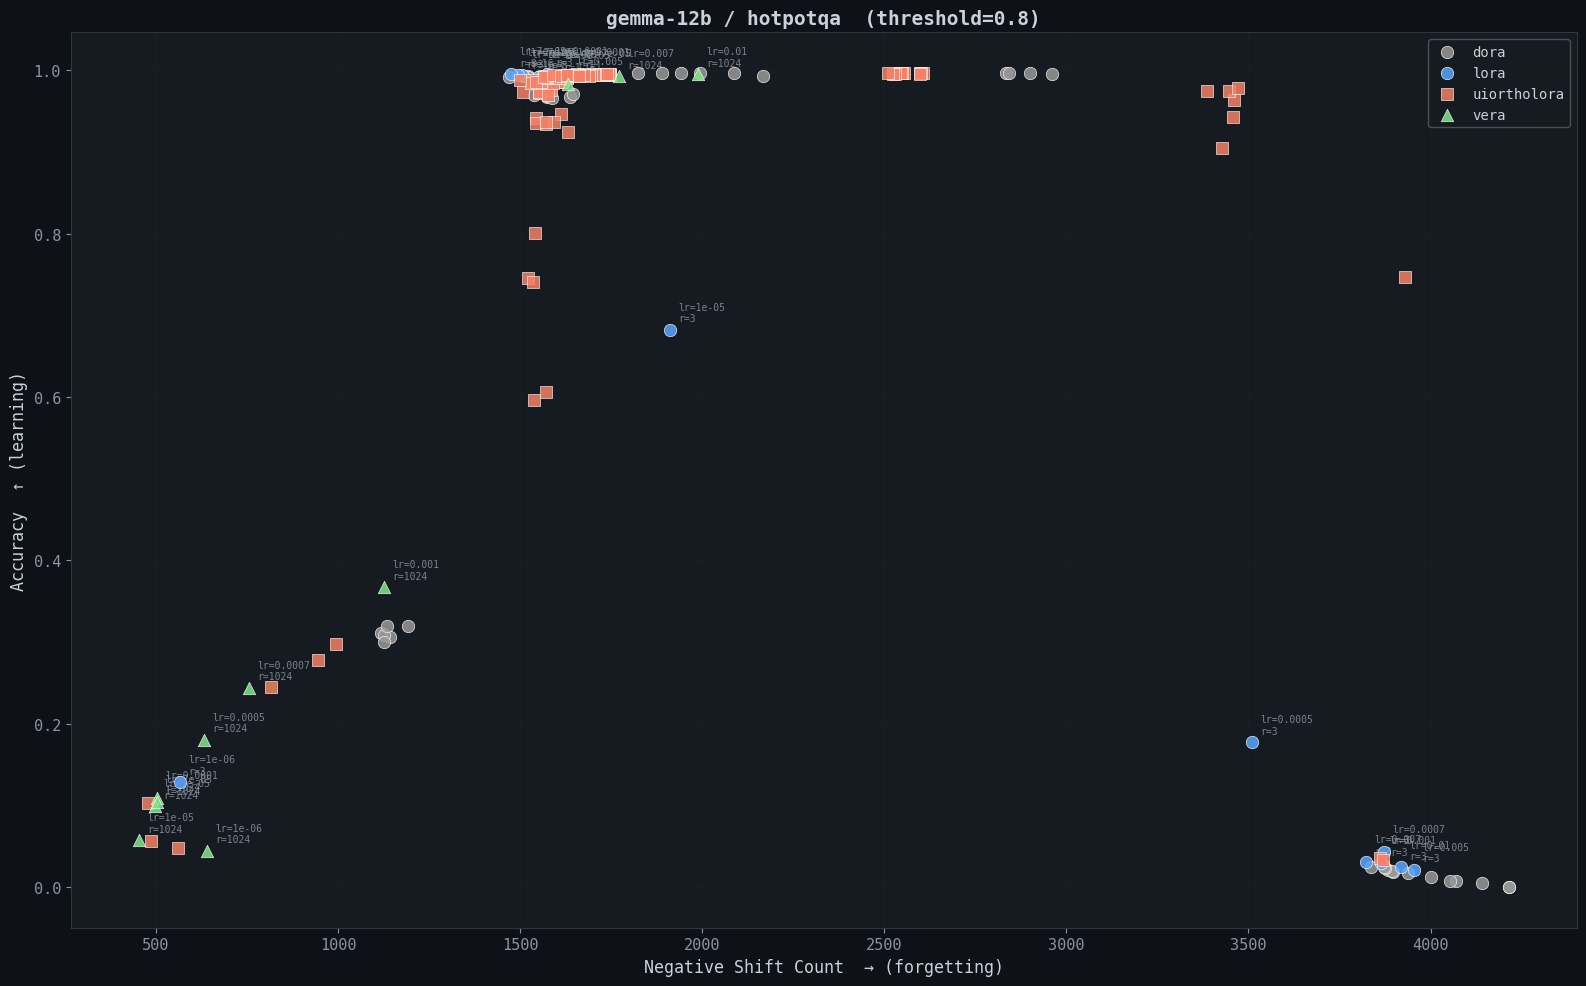


──────────────────────────────────────────────────────────────────────
  gemma-12b / hotpotqa  |  threshold=0.8  |  176 adapters
──────────────────────────────────────────────────────────────────────
  dora             n= 42  acc=[0.000–0.997]  neg=[1119–4214]
  lora             n= 18  acc=[0.021–0.996]  neg=[566–3955]
  uiortholora      n=105  acc=[0.034–0.997]  neg=[478–3931]
  vera             n= 11  acc=[0.045–0.996]  neg=[454–1989]



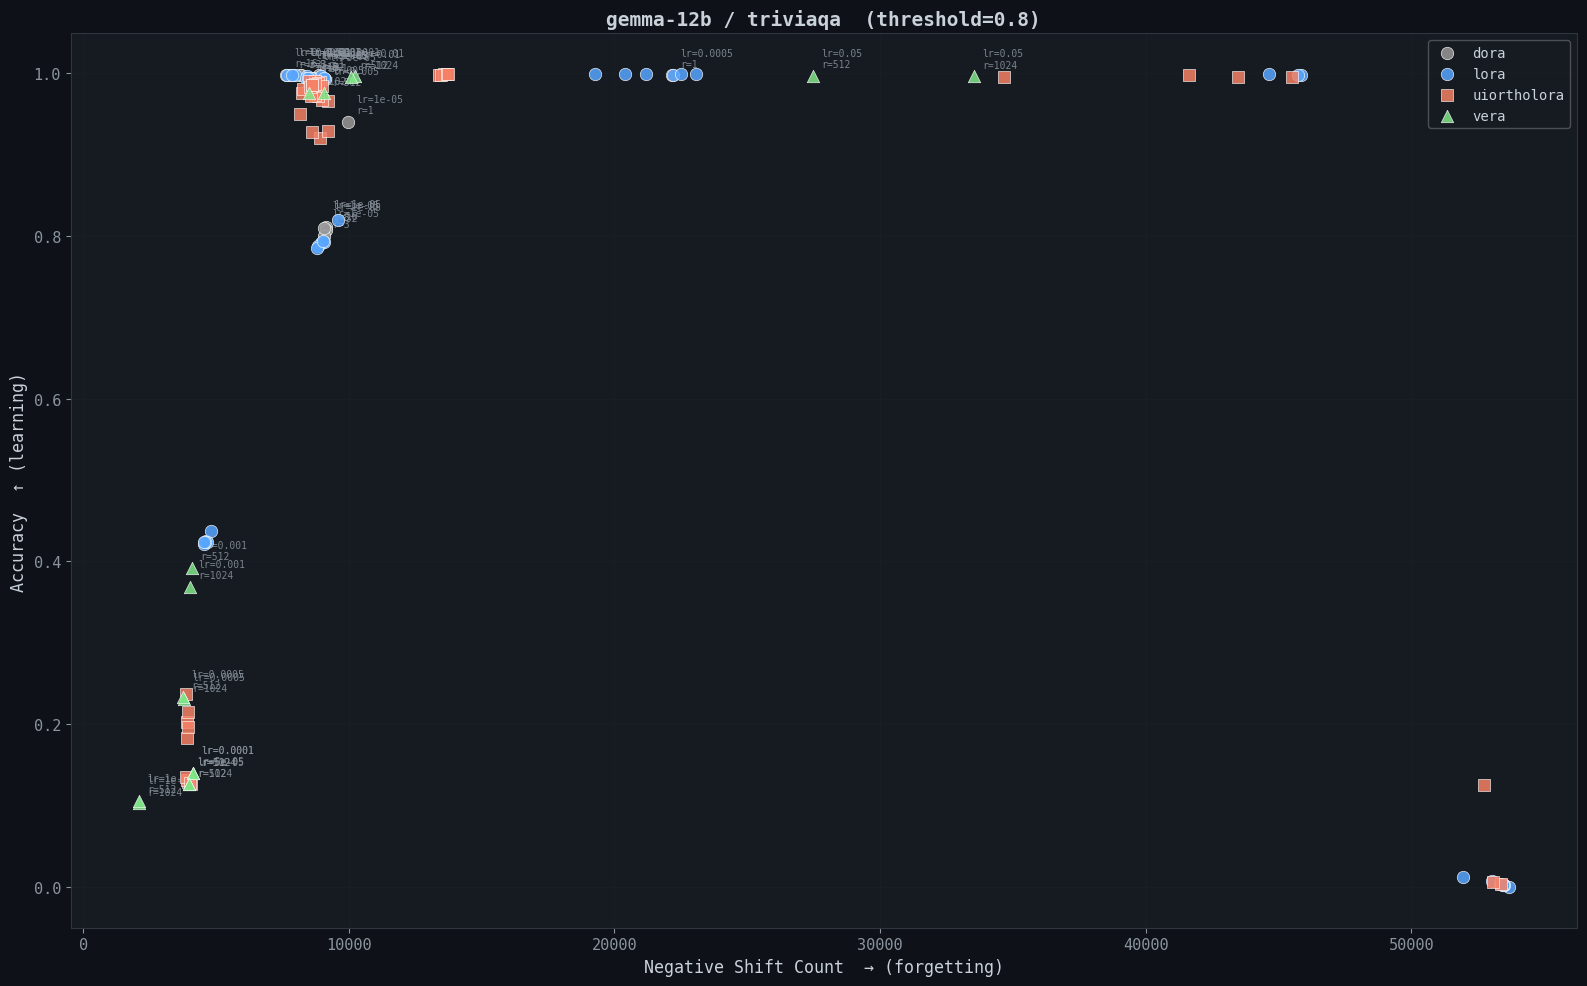


──────────────────────────────────────────────────────────────────────
  gemma-12b / triviaqa  |  threshold=0.8  |  119 adapters
──────────────────────────────────────────────────────────────────────
  dora             n= 16  acc=[0.800–0.998]  neg=[7645–22178]
  lora             n= 43  acc=[0.000–0.998]  neg=[4557–53664]
  uiortholora      n= 44  acc=[0.004–0.998]  neg=[3864–53390]
  vera             n= 16  acc=[0.103–0.996]  neg=[2107–33542]



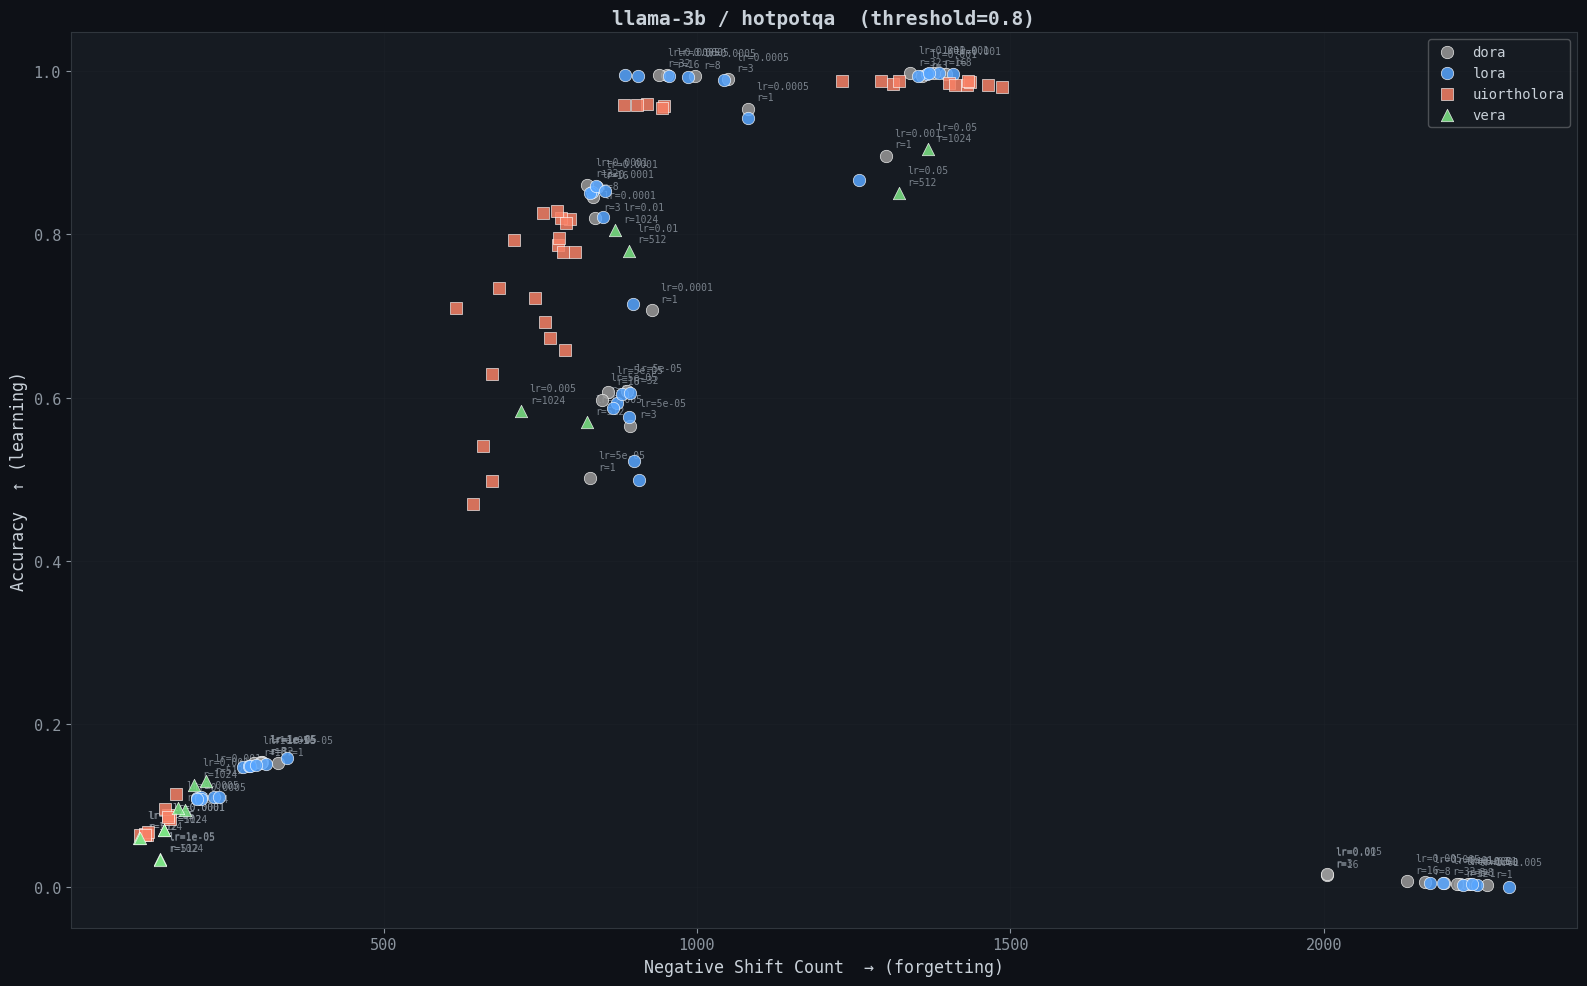


──────────────────────────────────────────────────────────────────────
  llama-3b / hotpotqa  |  threshold=0.8  |  140 adapters
──────────────────────────────────────────────────────────────────────
  dora             n= 35  acc=[0.002–0.998]  neg=[294–2261]
  lora             n= 43  acc=[0.000–0.998]  neg=[203–2295]
  uiortholora      n= 46  acc=[0.063–0.988]  neg=[112–1487]
  vera             n= 16  acc=[0.034–0.904]  neg=[110–1368]



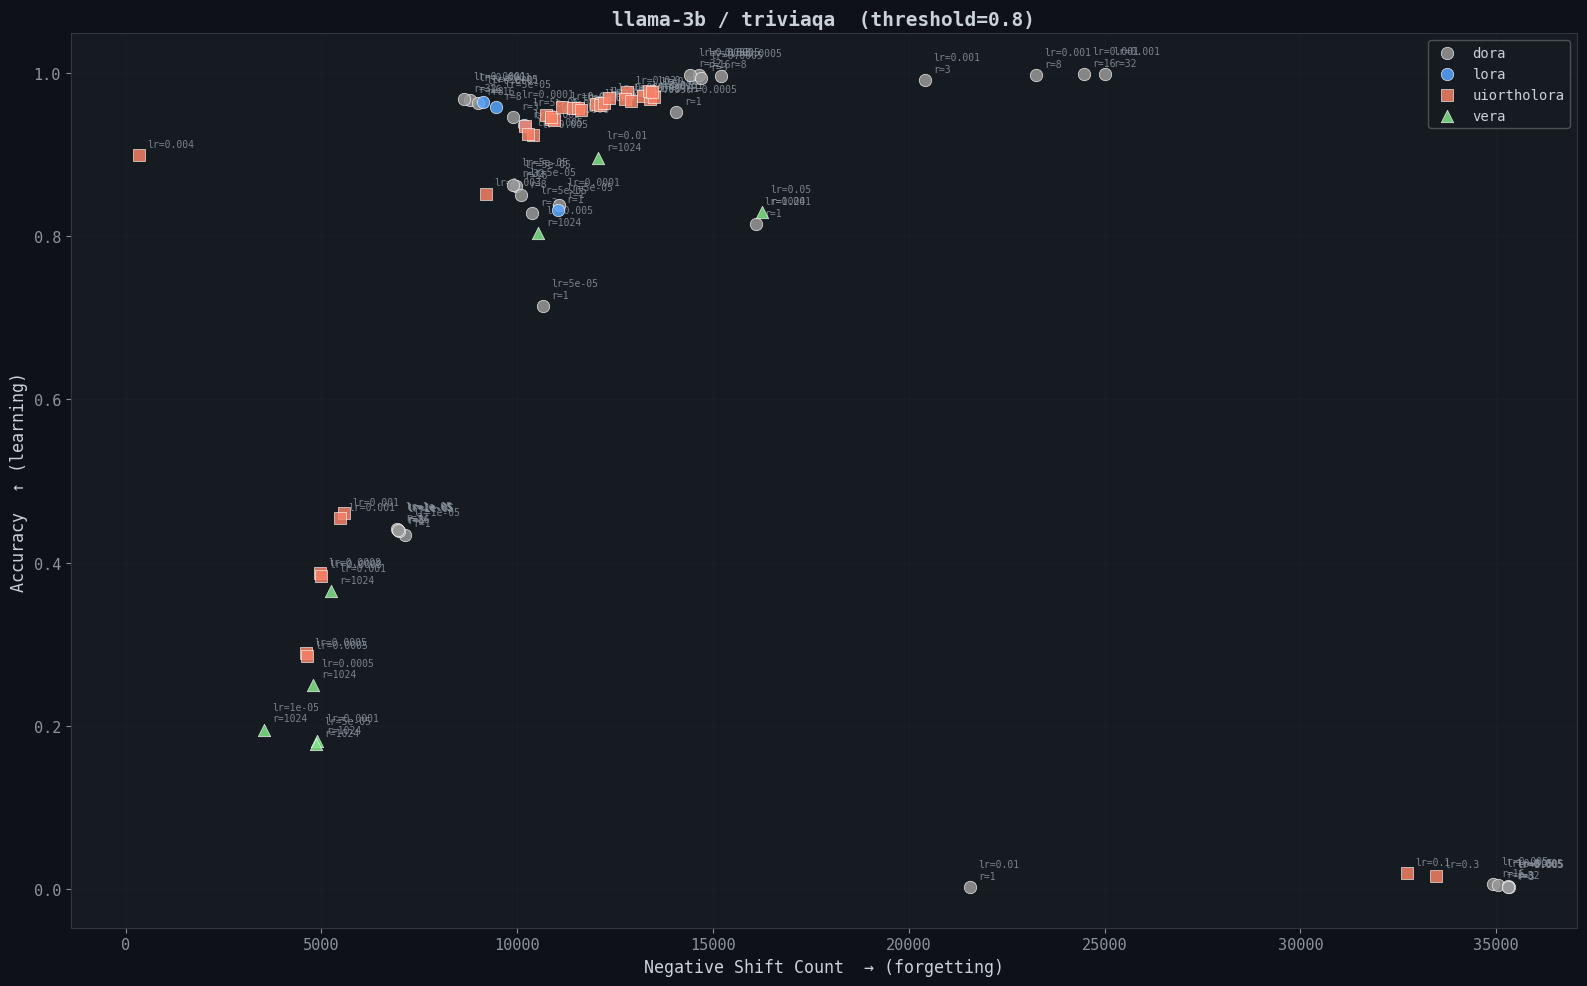


──────────────────────────────────────────────────────────────────────
  llama-3b / triviaqa  |  threshold=0.8  |  77 adapters
──────────────────────────────────────────────────────────────────────
  dora             n= 31  acc=[0.003–0.999]  neg=[6935–35315]
  lora             n=  4  acc=[0.832–0.964]  neg=[9132–11043]
  uiortholora      n= 34  acc=[0.017–0.978]  neg=[345–33472]
  vera             n=  8  acc=[0.178–0.896]  neg=[3536–16260]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  gemma-12b / hotpotqa  (threshold=0.8)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                                            adapter        type       lr   rank  accuracy  neg_shift   mmlu  bigbench
                                         dora_trAll_lora_r32_lr1e-5        dora 0.000010   32.0    0.3111       1119 0.7025    0.6072
                                          dora_trAll_lora_r8_l

In [11]:
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    fig, ax = plt.subplots(figsize=(16, 10))
    df = plot_scatter(model, dataset, THRESHOLD, ax)
    plt.tight_layout()
    plt.show()

    # Stats
    if not df.empty:
        print(f"\n{'─'*70}")
        print(f"  {model} / {dataset}  |  threshold={THRESHOLD}  |  {len(df)} adapters")
        print(f"{'─'*70}")
        for atype in sorted(df["adapter_type"].dropna().unique()):
            sub = df[df["adapter_type"] == atype]
            print(f"  {atype:15s}  n={len(sub):3d}  "
                  f"acc=[{sub['accuracy'].min():.3f}–{sub['accuracy'].max():.3f}]  "
                  f"neg=[{sub['negative_shift_count'].min()}–{sub['negative_shift_count'].max()}]")
        print()


# %% ── Cell 4: Run — Summary Tables with MMLU & BigBench ─────────────────────
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    print(f"\n{'━'*90}")
    print(f"  {model} / {dataset}  (threshold={THRESHOLD})")
    print(f"{'━'*90}")
    print_summary(model, dataset, THRESHOLD)
    print()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import re


def compute_pareto_front(x, y, direction='upper_right'):
    """
    Compute the Pareto front for a set of 2D points.
    
    direction: which corner is 'best'
        'upper_right' => maximize both x and y
        'upper_left'  => minimize x, maximize y
    
    Returns (is_pareto mask, points array).
    """
    points = np.column_stack([x, y])
    
    if direction == 'upper_right':
        is_pareto = np.ones(len(points), dtype=bool)
        for i, p in enumerate(points):
            for j, q in enumerate(points):
                if i != j and q[0] >= p[0] and q[1] >= p[1] and (q[0] > p[0] or q[1] > p[1]):
                    is_pareto[i] = False
                    break
    elif direction == 'upper_left':
        is_pareto = np.ones(len(points), dtype=bool)
        for i, p in enumerate(points):
            for j, q in enumerate(points):
                if i != j and q[0] <= p[0] and q[1] >= p[1] and (q[0] < p[0] or q[1] > p[1]):
                    is_pareto[i] = False
                    break
    else:
        raise ValueError(f"Unknown direction: {direction}")

    return is_pareto, points


def plot_adapter_pareto_panels(
    merged_mmlu, merged_bigbench,
    model, task,
    neg_shift_col='negative_shift_score',
    task_acc_col='accuracy',
    mmlu_col='mmlu_acc',
    bigbench_col='mean_accuracy',
    figsize=(18, 5),
    save_path=None,
    dpi=150
):
    """
    For each adapter type, create a 1x3 figure:
      [Task Acc vs Neg Shift] [Task Acc vs MMLU] [Task Acc vs BigBench]
    Each panel has points colored by LR, Pareto front line, and rank annotations.
    Pareto front values are printed to console.
    """
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    
    adapters_mmlu = set(merged_mmlu['adapter_type'].unique()) if not merged_mmlu.empty else set()
    adapters_bb = set(merged_bigbench['adapter_type'].unique()) if not merged_bigbench.empty else set()
    all_adapters = sorted(adapters_mmlu | adapters_bb)

    adapter_display = {
        'lora': 'LoRA',
        'dora': 'DoRA',
        'uiortholora': 'UIorthoLoRA',
        'vera': 'VeRA',
        'unknown': 'Unknown'
    }

    # Global LR range for consistent colorbar
    all_lrs = pd.concat([
        merged_mmlu['lr'].dropna() if not merged_mmlu.empty else pd.Series(dtype=float),
        merged_bigbench['lr'].dropna() if not merged_bigbench.empty else pd.Series(dtype=float),
    ])
    if all_lrs.empty or all_lrs.min() <= 0:
        norm = None
    else:
        norm = colors.LogNorm(vmin=all_lrs.min(), vmax=all_lrs.max())
    cmap = plt.cm.viridis

    for adapter in all_adapters:
        # Use GridSpec: 3 equal plot columns + 1 narrow colorbar column
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
        axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
        cbar_ax = fig.add_subplot(gs[0, 3])

        display_name = adapter_display.get(adapter, adapter)
        fig.suptitle(
            f'{display_name} — {task_label} on {model}',
            fontsize=16, fontweight='bold', y=1.02
        )

        print(f"\n{'='*60}")
        print(f"  PARETO FRONT: {display_name} — {task_label} on {model}")
        print(f"{'='*60}")

        # Determine neg_shift source
        if neg_shift_col in merged_mmlu.columns:
            src_neg = merged_mmlu
        elif neg_shift_col in merged_bigbench.columns:
            src_neg = merged_bigbench
        else:
            src_neg = pd.DataFrame()

        neg_sub = src_neg[src_neg['adapter_type'] == adapter].dropna(
            subset=[neg_shift_col, task_acc_col, 'lr']
        ) if not src_neg.empty else pd.DataFrame()

        mmlu_sub = merged_mmlu[merged_mmlu['adapter_type'] == adapter].dropna(
            subset=[mmlu_col, task_acc_col, 'lr']
        ) if not merged_mmlu.empty else pd.DataFrame()

        bb_sub = merged_bigbench[merged_bigbench['adapter_type'] == adapter].dropna(
            subset=[bigbench_col, task_acc_col, 'lr']
        ) if not merged_bigbench.empty else pd.DataFrame()

        panel_configs = [
            {
                'ax': axes[0], 'data': neg_sub,
                'x_col': neg_shift_col, 'y_col': task_acc_col,
                'x_label': 'Negative Shift (forgetting)',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_left',
                'title': 'vs Negative Shift'
            },
            {
                'ax': axes[1], 'data': mmlu_sub,
                'x_col': mmlu_col, 'y_col': task_acc_col,
                'x_label': 'MMLU Accuracy',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_right',
                'title': 'vs MMLU'
            },
            {
                'ax': axes[2], 'data': bb_sub,
                'x_col': bigbench_col, 'y_col': task_acc_col,
                'x_label': 'BigBench Accuracy',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_right',
                'title': 'vs BigBench'
            },
        ]

        sc = None
        for cfg in panel_configs:
            ax = cfg['ax']
            data = cfg['data']

            if data.empty:
                ax.set_title(cfg['title'], fontsize=13)
                ax.set_xlabel(cfg['x_label'], fontsize=11)
                ax.set_ylabel(cfg['y_label'], fontsize=11)
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
                ax.grid(True, linestyle='--', alpha=0.4)
                print(f"\n  [{cfg['title']}] No data available")
                continue

            x = data[cfg['x_col']].values
            y = data[cfg['y_col']].values
            lr = data['lr'].values
            ranks = data['rank'].values if 'rank' in data.columns else None
            names = data['merge_key'].values if 'merge_key' in data.columns else None

            # Scatter
            sc = ax.scatter(
                x, y, c=lr, norm=norm, cmap=cmap,
                s=100, alpha=0.85, edgecolors='k', linewidth=0.5, zorder=3
            )

            # Annotate rank
            if ranks is not None:
                for xi, yi, ri in zip(x, y, ranks):
                    if ri > 0:
                        ax.annotate(
                            f'r{ri}', (xi, yi),
                            textcoords='offset points', xytext=(5, 5),
                            fontsize=7, color='0.3', zorder=4
                        )

            # Pareto front
            if len(x) >= 2:
                is_pareto, points = compute_pareto_front(x, y, direction=cfg['pareto_dir'])
                pareto_points = points[is_pareto]
                order = np.argsort(pareto_points[:, 0])
                px, py = pareto_points[order, 0], pareto_points[order, 1]

                if len(px) >= 2:
                    ax.plot(px, py, 'r--', linewidth=2, alpha=0.7, label='Pareto front', zorder=2)
                ax.scatter(px, py, facecolors='none', edgecolors='red',
                           s=180, linewidths=1.8, zorder=5)

                # Print Pareto values
                pareto_indices = np.where(is_pareto)[0]
                print(f"\n  [{cfg['title']}] Pareto front ({len(pareto_indices)} points):")
                print(f"  {'Name':<45} {'Rank':>5} {'LR':>10} {cfg['x_col']:>15} {cfg['y_col']:>15}")
                print(f"  {'-'*95}")
                for idx in pareto_indices:
                    name_str = names[idx] if names is not None else '—'
                    rank_str = f"r{int(ranks[idx])}" if ranks is not None else '—'
                    print(f"  {name_str:<45} {rank_str:>5} {lr[idx]:>10.1e} {x[idx]:>15.4f} {y[idx]:>15.4f}")

            ax.set_title(cfg['title'], fontsize=13)
            ax.set_xlabel(cfg['x_label'], fontsize=11)
            ax.set_ylabel(cfg['y_label'], fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(fontsize=9, loc='best')

        # Shared colorbar in dedicated axes
        if sc and norm:
            fig.colorbar(sc, cax=cbar_ax, label='Learning Rate (log scale)')
        else:
            cbar_ax.set_visible(False)

        if save_path:
            import os
            os.makedirs(save_path, exist_ok=True)
            fname = f"{save_path}/{adapter}_{model}_{task}_pareto.pdf"
            fig.savefig(fname, dpi=dpi, bbox_inches='tight')
            print(f"\n  Saved: {fname}")

        plt.show()


def plot_all_configs(merged_mmlu, merged_bigbench, model, task,
                     neg_shift_col='negative_shift_score', save_path=None):
    """Drop-in replacement: call this instead of plot_config."""
    plot_adapter_pareto_panels(
        merged_mmlu, merged_bigbench,
        model=model, task=task,
        neg_shift_col=neg_shift_col,
        save_path=save_path
    )

In [ ]:
def extract_metadata(df, name_col='model_path'):
    """
    Extracts adapter_type, rank, and lr from a naming column if they are missing.
    Returns the dataframe with standardized columns.
    """
    df = df.copy()
    
    # 1. Standardize Adapter Type
    # If peft_method exists, use it; otherwise extract from name
    if 'peft_method' in df.columns:
        df['adapter_type'] = df['peft_method'].fillna('')
    else:
        df['adapter_type'] = ''
        
    # In extract_metadata, update get_adapter:
    def get_adapter(row):
        val = str(row.get('adapter_type', '')).lower()
        name = str(row[name_col]).lower()
        if val in ['lora', 'vera', 'uiortholora', 'dora']:
            return val
        if 'uiortho' in name: return 'uiortholora'
        if 'dora' in name: return 'dora'       # <-- BEFORE 'lora' check!
        if 'vera' in name: return 'vera'
        if 'lora' in name: return 'lora'
        return 'unknown'

    df['adapter_type'] = df.apply(get_adapter, axis=1)

    # 2. Extract Learning Rate (LR)
    def get_lr(row):
        # Prefer explicit column
        if 'learning_rate' in row and pd.notnull(row['learning_rate']):
            return float(row['learning_rate'])
        if 'lr' in row and pd.notnull(row['lr']):
            return float(row['lr'])
        
        # Regex extract from name (looks for lr1e-4, lr5e-5, etc.)
        match = re.search(r'lr([\de.-]+)', str(row[name_col]))
        if match:
            try:
                return float(match.group(1))
            except:
                return np.nan
        return np.nan

    df['lr'] = df.apply(get_lr, axis=1)

    # 3. Extract Rank/Size
    def get_rank(row):
        # Prefer explicit column
        if 'rank' in row and pd.notnull(row['rank']):
            return int(float(row['rank']))
        
        name = str(row[name_col])
        # Check for svXXXX (uiortholora)
        match_sv = re.search(r'_sv(\d+)', name)
        if match_sv: return int(match_sv.group(1))
        
        # Check for rXXXX (lora/vera)
        match_r = re.search(r'_r(\d+)', name)
        if match_r: return int(match_r.group(1))
        
        return 0

    df['rank'] = df.apply(get_rank, axis=1)
    
    return df

def align_and_merge(df_task, df_general, general_name_col='model_name', 
                    task_name_col='raw_adapter_name', suffixes=('_task', '_gen')):
    """
    Aligns task results with general benchmark results (MMLU, BigBench, etc.)
    by extracting the adapter name from potentially nested path columns.
    """
    df_general = df_general.copy()
    
    # Strip to just the adapter name (last path segment, remove 'models/' prefix)
    df_general['merge_key'] = (
        df_general[general_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    # Also normalize task side in case it has paths too
    df_task = df_task.copy()
    df_task['merge_key'] = (
        df_task[task_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    merged = pd.merge(
        df_task,
        df_general,
        on='merge_key',
        suffixes=suffixes
    )
    
    merged = extract_metadata(merged, name_col='merge_key')
    
    print(f"Merged rows: {len(merged)} "
          f"(task: {len(df_task)}, general: {len(df_general)}, "
          f"unmatched task: {len(df_task) - len(merged)})")
    
    return merged

In [22]:
def load_and_merge(model, task, threshold='0.8', filter_fn=None):
    """
    Load task, MMLU, and BigBench data for a given model/task config
    and return merged DataFrames ready for plotting.
    
    Parameters:
        model: 'gemma-12b' or 'llama-3b'
        task: 'triviaqa' or 'hotpotqa'
        threshold: threshold string (default '0.8')
        filter_fn: optional function to filter the merged DataFrames
    
    Returns:
        (merged_mmlu, merged_bigbench) tuple of DataFrames
    """
    file_path = f'adapters_results/{task}/threshold_{threshold}/{model}.csv'
    mmlu_path = f'adapters_results/{task}/mmlu_summary.csv'
    bigbench_path = f'adapters_results/{task}/bigbench_summary.csv'

    df_task = pd.read_csv(file_path)
    df_mmlu = pd.read_csv(mmlu_path)
    df_bigbench = pd.read_csv(bigbench_path)

    print(f"=== {model} / {task} ===")
    merged_mmlu = align_and_merge(df_task, df_mmlu, general_name_col='model_name')
    merged_bigbench = align_and_merge(df_task, df_bigbench, general_name_col='model_path')

    if filter_fn:
        merged_mmlu = filter_fn(merged_mmlu)
        merged_bigbench = filter_fn(merged_bigbench)
        print(f"After filter: MMLU={len(merged_mmlu)}, BigBench={len(merged_bigbench)}")

    return merged_mmlu, merged_bigbench

In [23]:
lora_r1_plus_others = lambda df: df[(df['adapter_type'] != 'lora') | (df['rank'] == 1)]
final_filter = lambda df: df
# final_filter = lora_r1_plus_others

# Load all 4 configs
gemma_trivia_mmlu, gemma_trivia_bb = load_and_merge('gemma-12b', 'triviaqa', filter_fn=final_filter)
gemma_hotpot_mmlu, gemma_hotpot_bb = load_and_merge('gemma-12b', 'hotpotqa', filter_fn=final_filter)
llama_trivia_mmlu, llama_trivia_bb = load_and_merge('llama-3b', 'triviaqa', filter_fn=final_filter)
llama_hotpot_mmlu, llama_hotpot_bb = load_and_merge('llama-3b', 'hotpotqa', filter_fn=final_filter)

# Plot any of them
def plot_config(merged_mmlu, merged_bigbench, model, task):
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    
    plot_performance_tradeoff(
        merged_mmlu, x_col='mmlu_acc', y_col='accuracy',
        title=f'{task_label} vs MMLU ({model})',
        x_label='MMLU Accuracy',
        y_label=f'{task_label} Accuracy'
    )
    plot_performance_tradeoff(
        merged_bigbench, x_col='mean_accuracy', y_col='accuracy',
        title=f'{task_label} vs BigBench ({model})',
        x_label='BigBench Accuracy',
        y_label=f'{task_label} Accuracy'
    )

=== gemma-12b / triviaqa ===
Merged rows: 142 (task: 122, general: 187, unmatched task: -20)
Merged rows: 148 (task: 122, general: 193, unmatched task: -26)
After filter: MMLU=142, BigBench=148
=== gemma-12b / hotpotqa ===
Merged rows: 218 (task: 201, general: 314, unmatched task: -17)
Merged rows: 222 (task: 201, general: 322, unmatched task: -21)
After filter: MMLU=218, BigBench=222
=== llama-3b / triviaqa ===
Merged rows: 108 (task: 99, general: 187, unmatched task: -9)
Merged rows: 110 (task: 99, general: 193, unmatched task: -11)
After filter: MMLU=108, BigBench=110
=== llama-3b / hotpotqa ===
Merged rows: 173 (task: 141, general: 314, unmatched task: -32)
Merged rows: 178 (task: 141, general: 322, unmatched task: -37)
After filter: MMLU=173, BigBench=178



  PARETO FRONT: DoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (14 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  dora_trAll_lora_r16_lr1e-4                      r16    1.0e-04       1546.1000          0.9932
  dora_trAll_lora_r16_lr1e-4                      r16    1.0e-04       1546.1000          0.9932
  dora_trAll_lora_r32_lr1e-4                      r32    1.0e-04       1515.5000          0.9929
  dora_trAll_lora_r32_lr1e-4                      r32    1.0e-04       1515.5000          0.9929
  dora_trAll_lora_r3_lr1e-4                        r3    1.0e-04       1510.3000          0.9918
  dora_trAll_lora_r3_lr1e-4                        r3    1.0e-04       1510.3000          0.9918
  dora_trAll_lora_r8_lr1e-4                        r8    1.0e-04       1461.2000          0.9916
  dora_trAll_lora_r8_lr1e-4 

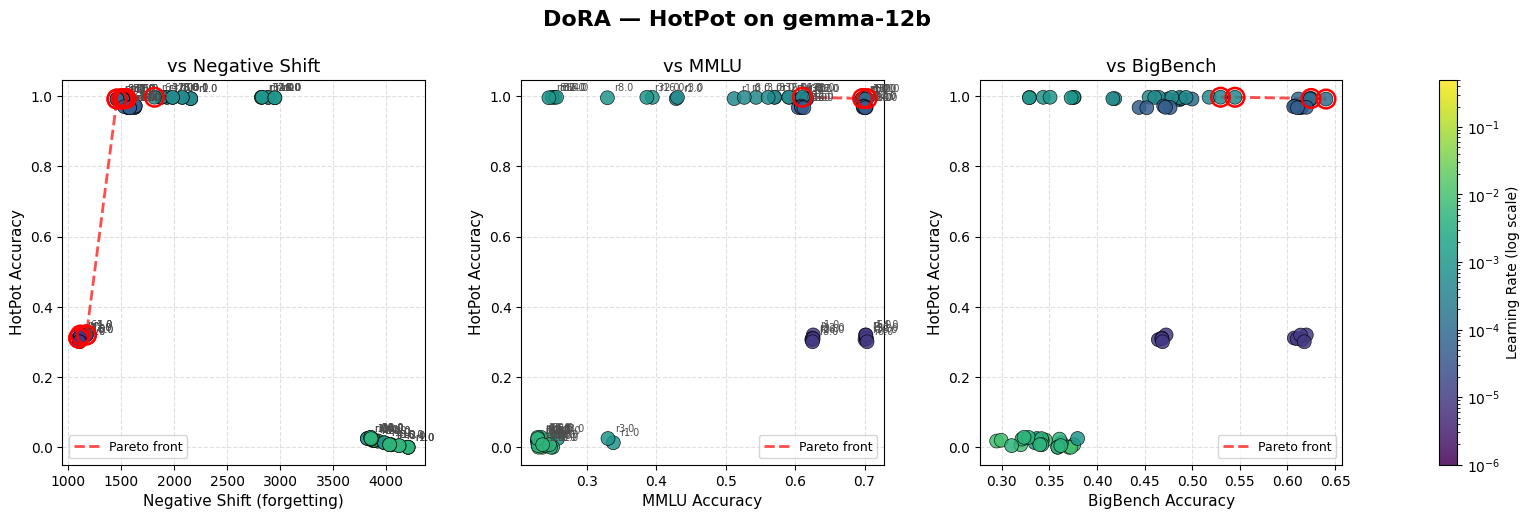


  PARETO FRONT: LoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (3 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4    r3    1.0e-04       1564.5000          0.9961
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6    r3    1.0e-06        548.1000          0.1283
  google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5    r8    7.0e-05       1468.5000          0.9956

  [vs MMLU] Pareto front (5 points):
  Name                                           Rank         LR        mmlu_acc        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4    r3    1.0e-04          0.6911          0.9961
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6    r3    1.0e-06          0.7

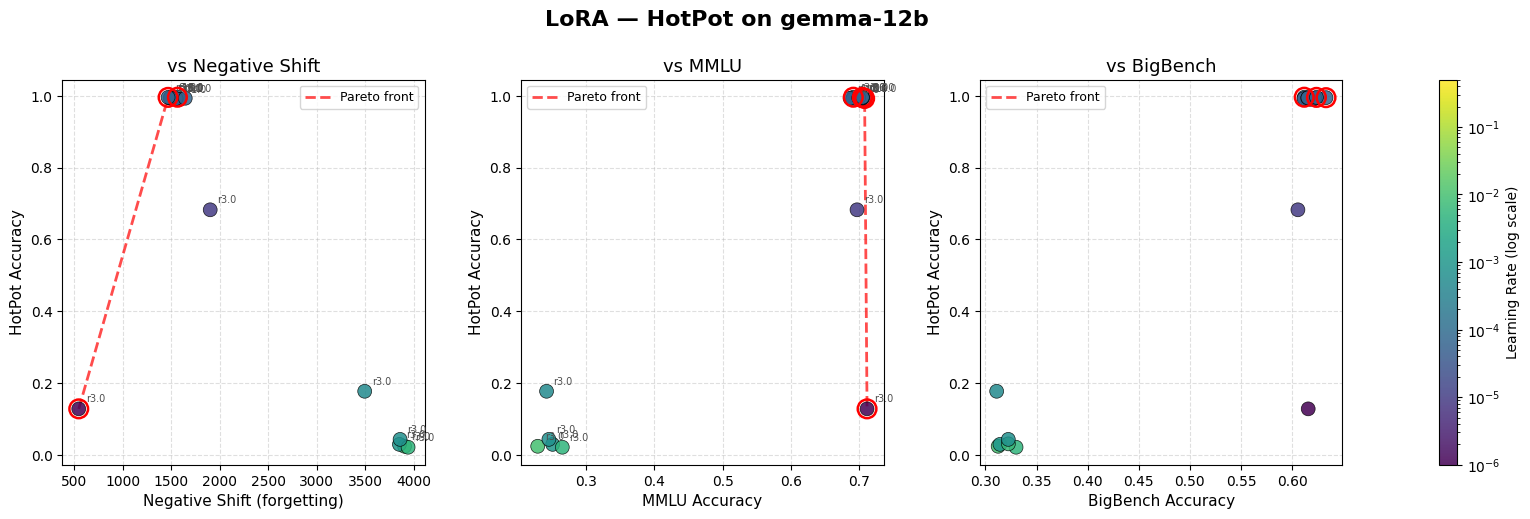


  PARETO FRONT: UIorthoLoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (17 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------


ValueError: cannot convert float NaN to integer

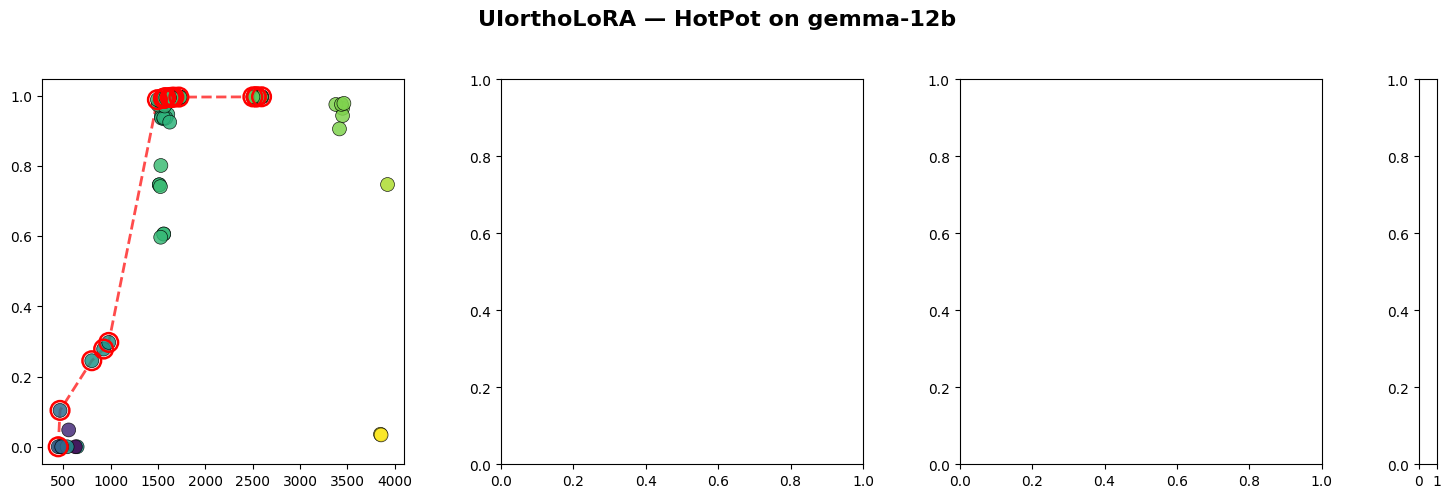

In [24]:
plot_all_configs(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpot', 'negative_shift_score')